<a href="https://colab.research.google.com/github/D2718281828nis/BioMedAI-Heart-Desease-LifeTime-Forecast/blob/main/Survival-function-analysys.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Load libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC

import shap

import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

# Load dataset

In [2]:
data_link = "https://github.com/D2718281828nis/BioMedAI-Heart-Desease-LifeTime-Forecast/raw/refs/heads/main/med_dataset_cardio.xlsx"
data = pd.read_excel(data_link, header=0)
data.rename(columns={"0_na, 1_mi": "severity", "0_no, 1_ther, 2_card": "doctor"}, inplace=True);
data.drop(columns=["card"], inplace=True)
data.drop(columns=["na"], inplace=True)
data.drop(columns=["dmonit"], inplace=True)
data["target"] = data["result_cvd"]
data.drop(columns=["result", "result_cvd"], inplace=True)

from sklearn.utils import resample
from imblearn.over_sampling import SMOTE

df_raw = data.copy()

# Separate majority and minority classes
df_majority = df_raw[df_raw['target'] == 0]
df_minority = df_raw[df_raw['target'] == 1]

print(f"\nClass 0 samples: {len(df_majority)}")
print(f"Class 1 samples: {len(df_minority)}")


Class 0 samples: 1354
Class 1 samples: 152


# Method 0: baseline - get balanced data, exclude late enter patient

In [3]:
df = df_raw
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1506 entries, 0 to 1505
Data columns (total 32 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   doctor        1506 non-null   int64  
 1   time          1506 non-null   int64  
 2   age           1506 non-null   float64
 3   af            1506 non-null   int64  
 4   dm            1506 non-null   int64  
 5   ckd           1506 non-null   int64  
 6   copd          1506 non-null   int64  
 7   insult        1506 non-null   int64  
 8   onco          1506 non-null   int64  
 9   severity      1506 non-null   int64  
 10  nstemi        1506 non-null   int64  
 11  stemi         1506 non-null   int64  
 12  llo           1506 non-null   int64  
 13  gender        1506 non-null   int64  
 14  ca_delay      1506 non-null   int64  
 15  sum_cad       1506 non-null   int64  
 16  stenting      1506 non-null   int64  
 17  total_revasc  1506 non-null   int64  
 18  ef_hosp       1506 non-null 

In [4]:
y = df['time']

columns_to_drop_for_regressor = ['time', 'target']

#if 'age_group' in df_upsampled.columns:
#    columns_to_drop_for_regressor.append('age_group')

X = df.drop(columns=columns_to_drop_for_regressor)

In [5]:
# Store the feature names that gb_reg was trained on
original_features = X.columns.tolist()

#делим выборку на тестовую и тренировочную
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=37
)

#данные имеют разную природу, поэтому нужно их стандартизовать
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

Train: (1204, 30)  |  Test: (302, 30)


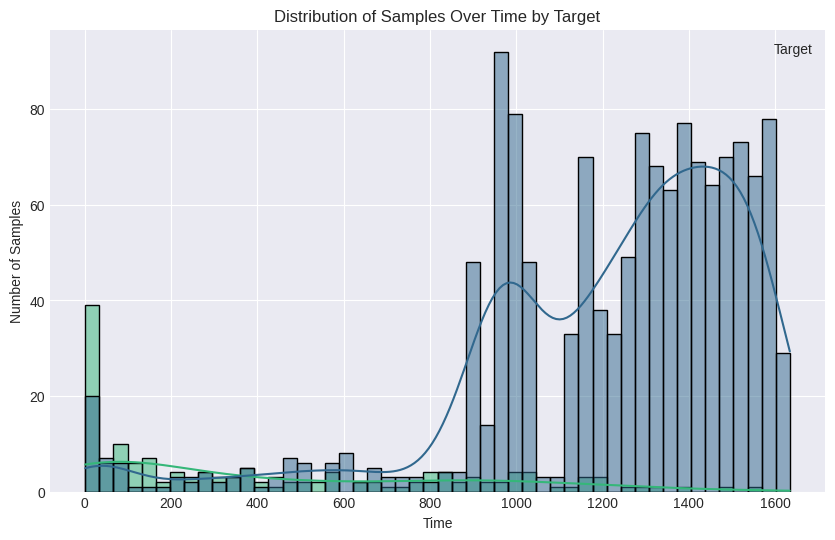

In [6]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df_raw, x='time', hue='target', kde=True, palette='viridis', bins=50)
plt.title('Distribution of Samples Over Time by Target')
plt.xlabel('Time')
plt.ylabel('Number of Samples')
plt.legend(title='Target')
plt.grid(True)
plt.show()

In [7]:
# Retake dataframe from df_raw for survival analysis specific split
print("Applying new data split for survival analysis based on 'target' column.")

# Separate data based on the 'target' column
# Samples with target = 1 (died patient) for training, specifically with time > 1400
df_balanced = df_raw[(df_raw['target'] == 1) | (df_raw['target'] == 0) & (df_raw['time'] > 1500)].copy()

# Samples with target = 0 (lived person) for proving survival function
# Exclude samples where time < 1500 for target = 0
df_survival_proof = df_raw[(df_raw['target'] == 0) & (df_raw['time'] >= 1500)].copy()

df = df_balanced.copy()

# Ensure 'columns_to_drop_for_regressor' is defined
if 'columns_to_drop_for_regressor' not in locals():
    columns_to_drop_for_regressor = ['time', 'target']

# Define features (X) and duration (y) for the new training set
X_balanced = df_balanced.drop(columns=columns_to_drop_for_regressor)
y_balanced = df_balanced['time']

# Define features (X) and duration (y) for the new proving set
X_proof = df_survival_proof.drop(columns=columns_to_drop_for_regressor)
y_proof = df_survival_proof['time']

# Store the feature names (important for SHAP and lifelines models)
original_features = X_balanced.columns.tolist()

# Standardize the data using StandardScaler
# Ensure 'scaler' is initialized
if 'scaler' not in locals():
    scaler = StandardScaler()

X_balanced_sc = scaler.fit_transform(X_balanced)
X_proof_sc  = scaler.transform(X_proof)


#делим выборку на тестовую и тренировочную
X_train_sc, X_test_sc, y_train, y_test = train_test_split(
    X_balanced_sc, y_balanced, test_size=0.2, random_state=37
)

print(f"New Train set shape (target=1, time > 1400): {X_train_sc.shape} (N={len(y_train)} events)")
print(f"New Test set shape (target=0): {X_test_sc.shape} (N={len(y_test)} censored)")

# Update event and time arrays for lifelines models
event_train = df_balanced["target"].astype(bool).values # All true for training (as per request)
time_train = df_balanced["time"].astype(float).values

event_test = df_survival_proof["target"].astype(bool).values   # All false for testing (as per request)
time_test = df_survival_proof["time"].astype(float).values

# Set 'df' to df_raw to ensure consistency for subsequent steps that might refer to 'df'
# The user requested 'df' to remain the main dataset, not a filtered subset.


Applying new data split for survival analysis based on 'target' column.
New Train set shape (target=1, time > 1400): (325, 30) (N=325 events)
New Test set shape (target=0): (82, 30) (N=82 censored)


In [8]:
# Separate majority and minority classes
df_majority = df[df['target'] == 0]
df_minority = df[df['target'] == 1]

print(f"\nClass 0 samples: {len(df_majority)}")
print(f"Class 1 samples: {len(df_minority)}")


Class 0 samples: 255
Class 1 samples: 152


## Method 1: Downsample majority class to match minority class

In [9]:

# # Method 1: Downsample majority class to match minority class
# df_majority_downsampled = resample(df_majority,
#                                    replace=False,  # sample without replacement
#                                    n_samples=len(df_minority),  # match minority class size
#                                    random_state=37)  # reproducible results

# # Combine downsampled majority with minority
# df_downsampled = pd.concat([df_majority_downsampled, df_minority])

# print(f"\nAfter downsampling - balanced dataset:")
# print(df_downsampled['target'].value_counts())
# print(f"Total samples after downsampling: {len(df_downsampled)}")

# y = df_downsampled['time']

# columns_to_drop_for_regressor = ['time', 'target']

# #if 'age_group' in df_upsampled.columns:
# #    columns_to_drop_for_regressor.append('age_group')

# X = df_downsampled.drop(columns=columns_to_drop_for_regressor)


# # Store the feature names that gb_reg was trained on
# original_features = X.columns.tolist()

# #делим выборку на тестовую и тренировочную
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=37
# )

# #данные имеют разную природу, поэтому нужно их стандартизовать
# scaler = StandardScaler()
# X_train_sc = scaler.fit_transform(X_train)
# X_test_sc  = scaler.transform(X_test)

# print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

# df = df_downsampled

## Method 2: Upsample minority class using SMOTE to match majority class

In [10]:
# # Method 2: Upsample minority class using SMOTE to match majority class
# # Prepare data for SMOTE: features and target
# X_smote = df_raw.drop('target', axis=1)
# y_smote = df_raw['target']

# smote = SMOTE(random_state=37)
# X_resampled, y_resampled = smote.fit_resample(X_smote, y_smote)

# # Combine resampled features and target into a new DataFrame
# df_upsampled = pd.concat([X_resampled, y_resampled], axis=1)

# print(f"\nAfter upsampling with SMOTE - balanced dataset:")
# print(df_upsampled['target'].value_counts())
# print(f"Total samples after upsampling: {len(df_upsampled)}")

# y = df_upsampled['time']

# columns_to_drop_for_regressor = ['time', 'target']

# #if 'age_group' in df_upsampled.columns:
# #    columns_to_drop_for_regressor.append('age_group')

# X = df_upsampled.drop(columns=columns_to_drop_for_regressor)

# # Store the feature names that gb_reg was trained on
# original_features = X.columns.tolist()

# #делим выборку на тестовую и тренировочную
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=37
# )

# #данные имеют разную природу, поэтому нужно их стандартизовать
# scaler = StandardScaler()
# X_train_sc = scaler.fit_transform(X_train)
# X_test_sc  = scaler.transform(X_test)

# print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

# df = df_upsampled

# 0. Решаем задачу регрессии для time

In [11]:
# линейная регрессия
lr = LinearRegression()
lr.fit(X_train_sc, y_train)

y_pred_lr = lr.predict(X_test_sc)

lr_r2   = r2_score(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_mae  = mean_absolute_error(y_test, y_pred_lr)

print("Linear Regression")
print(f"  R²   = {lr_r2:.4f}")
print(f"  RMSE = {lr_rmse:.4f}")
print(f"  MAE  = {lr_mae:.4f}")
print(f"\nКоэффициенты модели:")
coef_df = pd.DataFrame({'feature': X.columns, 'coef': lr.coef_}).sort_values('coef')
print(coef_df.to_string(index=False))

Linear Regression
  R²   = 0.4539
  RMSE = 470.7217
  MAE  = 370.6489

Коэффициенты модели:
     feature        coef
         glu -149.034309
     sum_cad -127.223921
   pulm_cong -103.352334
         age  -79.806009
         bpm  -73.316069
          af  -70.013196
         ldl  -58.518550
     smoking  -50.451353
      insult  -42.618917
    severity  -37.100866
total_revasc  -29.753626
        crea  -27.233009
      nstemi  -24.211288
         ckd  -20.661185
       stemi  -19.645374
       sysAP   -9.009865
      gender   -7.240033
    ca_delay    5.168417
     tromboc    7.298386
        copd   10.044052
         llo   23.762831
         bmi   26.374482
      leukoc   29.623318
        onco   32.540115
     ef_hosp   40.066204
          hb   57.097058
    stenting   62.538108
      doctor  128.167295
          dm  143.218752
      t_chol  153.642761


In [12]:
# деревья решений
dt_reg = DecisionTreeRegressor(random_state=37, max_depth=10)
dt_reg.fit(X_train_sc, y_train)

y_pred_dt = dt_reg.predict(X_test_sc)

dt_r2   = r2_score(y_test, y_pred_dt)
dt_rmse = np.sqrt(mean_squared_error(y_test, y_pred_dt))
dt_mae  = mean_absolute_error(y_test, y_pred_dt)

# Train vs Test — проверяем переобучение
dt_r2_train = r2_score(y_train, dt_reg.predict(X_train_sc))

print("Decision Tree (max_depth=10)")
print(f"  Train R² = {dt_r2_train:.4f}")
print(f"  Test  R² = {dt_r2:.4f}")
print(f"  RMSE     = {dt_rmse:.4f}")
print(f"  MAE      = {dt_mae:.4f}")
if dt_r2_train - dt_r2 > 0.1:
    print("Внимание: разрыв Train/Test > 0.1 — возможно переобучение!")

Decision Tree (max_depth=10)
  Train R² = 0.9991
  Test  R² = -0.4721
  RMSE     = 772.8632
  MAE      = 536.6324
Внимание: разрыв Train/Test > 0.1 — возможно переобучение!


Random Forest (100 деревьев, max_depth=10)
  R²   = 0.4584
  RMSE = 468.7718
  MAE  = 379.5467


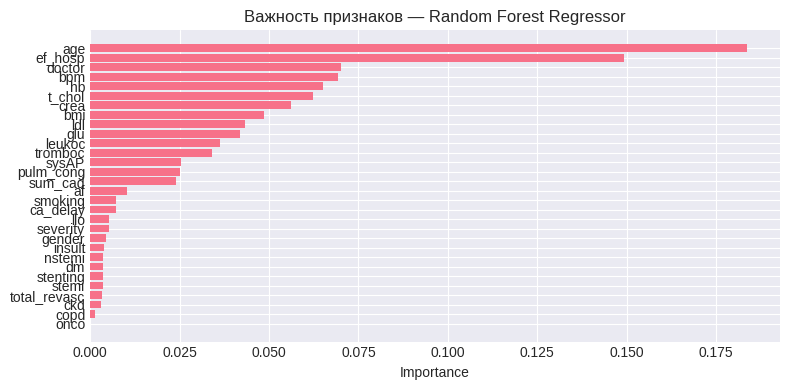

In [13]:
# случайный лес
rf_reg = RandomForestRegressor(n_estimators=500, random_state=42, max_depth=30)
rf_reg.fit(X_train_sc, y_train)

y_pred_rf = rf_reg.predict(X_test_sc)

rf_r2   = r2_score(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_mae  = mean_absolute_error(y_test, y_pred_rf)

print("Random Forest (100 деревьев, max_depth=10)")
print(f"  R²   = {rf_r2:.4f}")
print(f"  RMSE = {rf_rmse:.4f}")
print(f"  MAE  = {rf_mae:.4f}")

# Важность признаков
feat_imp = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_reg.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(feat_imp['feature'], feat_imp['importance'])
plt.title('Важность признаков — Random Forest Regressor')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

Gradient Boosting (100 деревьев, max_depth=5)
  R²   = 0.3836
  RMSE = 500.1298
  MAE  = 391.3473


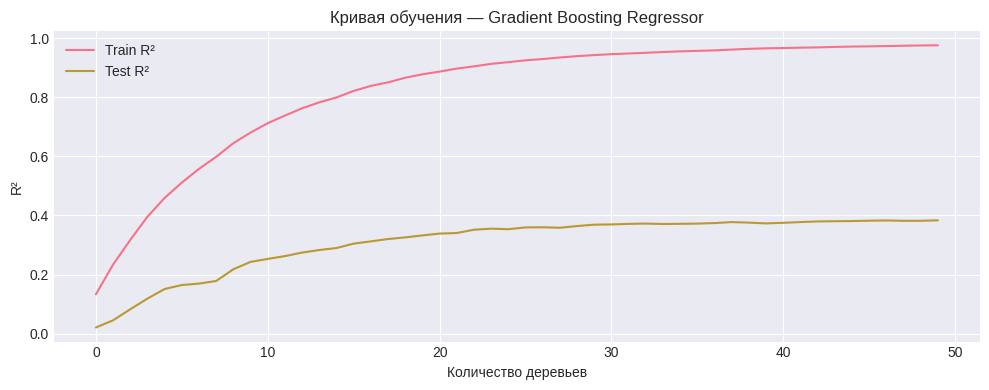

In [14]:
# градиентный бустинг
gb_reg = GradientBoostingRegressor(n_estimators=50, random_state=42, max_depth=5)
gb_reg.fit(X_train_sc, y_train)

y_pred_gb = gb_reg.predict(X_test_sc)

gb_r2   = r2_score(y_test, y_pred_gb)
gb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))
gb_mae  = mean_absolute_error(y_test, y_pred_gb)

print("Gradient Boosting (100 деревьев, max_depth=5)")
print(f"  R²   = {gb_r2:.4f}")
print(f"  RMSE = {gb_rmse:.4f}")
print(f"  MAE  = {gb_mae:.4f}")

# Кривая обучения (staged_predict)
train_scores = [r2_score(y_train, y_pred) for y_pred in gb_reg.staged_predict(X_train_sc)]
test_scores  = [r2_score(y_test,  y_pred) for y_pred in gb_reg.staged_predict(X_test_sc)]

plt.figure(figsize=(10, 4))
plt.plot(train_scores, label='Train R²', linewidth=1.5)
plt.plot(test_scores,  label='Test R²',  linewidth=1.5)
plt.xlabel('Количество деревьев')
plt.ylabel('R²')
plt.title('Кривая обучения — Gradient Boosting Regressor')
plt.legend()
plt.tight_layout()
plt.show()

Сводная таблица — Регрессия:
                       R²      RMSE       MAE
Model                                        
Linear Regression  0.4539  470.7217  370.6489
Decision Tree     -0.4721  772.8632  536.6324
Random Forest      0.4584  468.7718  379.5467
Gradient Boosting  0.3836  500.1298  391.3473

Лучшая модель по R²: Random Forest (0.4584)


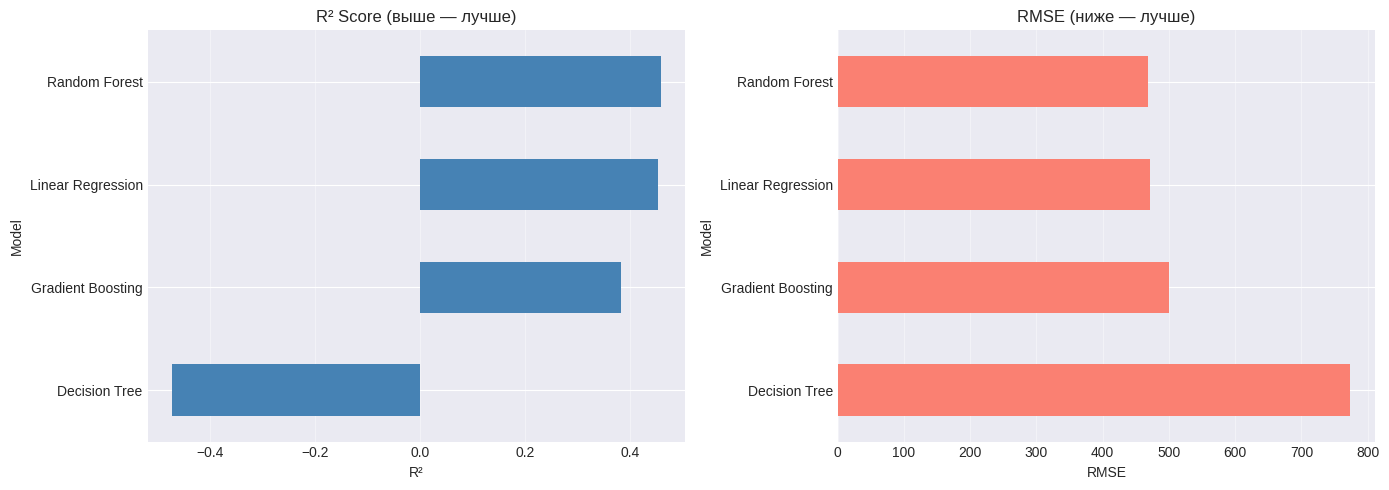

In [15]:
# сравниваем методы
reg_summary = pd.DataFrame({
    'Model': ['Linear Regression',
              'Decision Tree', 'Random Forest', 'Gradient Boosting'],
    'R²':   [lr_r2, dt_r2, rf_r2, gb_r2],
    'RMSE': [lr_rmse, dt_rmse, rf_rmse, gb_rmse],
    'MAE':  [lr_mae,  dt_mae,  rf_mae,  gb_mae]
}).set_index('Model').round(4)

print("Сводная таблица — Регрессия:")
print(reg_summary.to_string())

best_reg = reg_summary['R²'].idxmax()
print(f"\nЛучшая модель по R²: {best_reg} ({reg_summary.loc[best_reg, 'R²']:.4f})")

# График сравнения R²
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

reg_summary['R²'].sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('R² Score (выше — лучше)')
axes[0].set_xlabel('R²')
axes[0].grid(axis='x', alpha=0.4)

reg_summary['RMSE'].sort_values(ascending=False).plot(kind='barh', ax=axes[1], color='salmon')
axes[1].set_title('RMSE (ниже — лучше)')
axes[1].set_xlabel('RMSE')
axes[1].grid(axis='x', alpha=0.4)

plt.tight_layout()
plt.show()

#для лучшей модели
best_pred_map = {
    'Linear Regression': y_pred_lr,
    'Decision Tree': y_pred_dt,
    'Random Forest': y_pred_rf,
    'Gradient Boosting': y_pred_gb
}

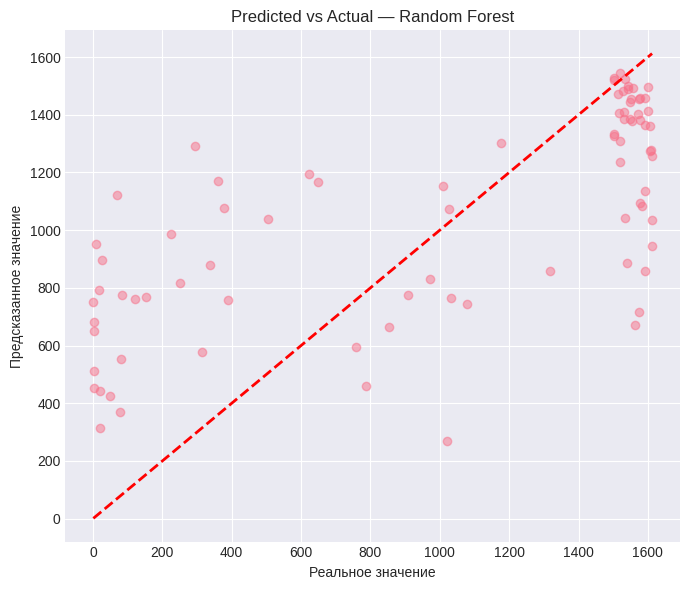

In [16]:
y_best = best_pred_map[best_reg]

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_best, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Реальное значение')
plt.ylabel('Предсказанное значение')
plt.title(f'Predicted vs Actual — {best_reg}')
plt.tight_layout()
plt.show()

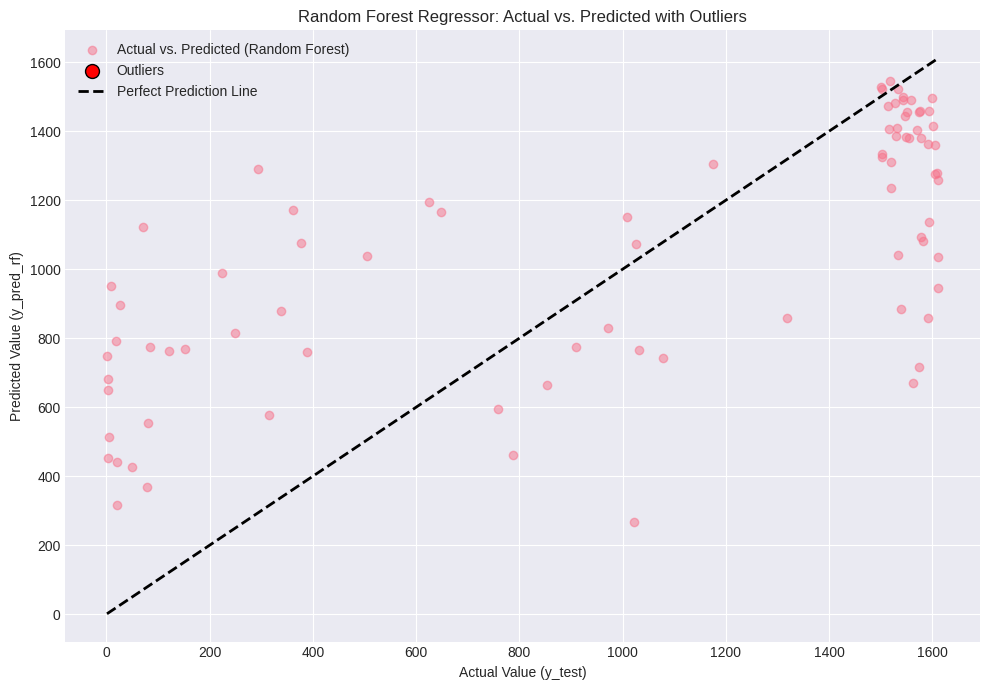


Number of outlier predictions: 0
Lower bound for residual outliers: -1502.37
Upper bound for residual outliers: 1260.39

--- Outlier Samples (Actual vs. Predicted) ---
Empty DataFrame
Columns: [Actual, Predicted, Residual]
Index: []


In [17]:
# Calculate residuals (errors)
residuals = y_test - y_pred_rf

# Calculate IQR for residuals
Q1_res = residuals.quantile(0.25)
Q3_res = residuals.quantile(0.75)
IQR_res = Q3_res - Q1_res

lower_bound_res = Q1_res - 1.5 * IQR_res
upper_bound_res = Q3_res + 1.5 * IQR_res

# Identify outlier residuals
outlier_mask = (residuals < lower_bound_res) | (residuals > upper_bound_res)

outlier_y_test = y_test[outlier_mask]
outlier_y_pred_rf = y_pred_rf[outlier_mask]

# Plotting actual vs. predicted values with outliers highlighted
plt.figure(figsize=(10, 7))
plt.scatter(y_test, y_pred_rf, alpha=0.5, label='Actual vs. Predicted (Random Forest)')
plt.scatter(outlier_y_test, outlier_y_pred_rf, color='red', s=100, label='Outliers', edgecolors='black')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Perfect Prediction Line')
plt.xlabel('Actual Value (y_test)')
plt.ylabel('Predicted Value (y_pred_rf)')
plt.title('Random Forest Regressor: Actual vs. Predicted with Outliers')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"\nNumber of outlier predictions: {len(outlier_y_test)}")
print(f"Lower bound for residual outliers: {lower_bound_res:.2f}")
print(f"Upper bound for residual outliers: {upper_bound_res:.2f}")

print("\n--- Outlier Samples (Actual vs. Predicted) ---")
outlier_df = pd.DataFrame({'Actual': outlier_y_test, 'Predicted': outlier_y_pred_rf, 'Residual': residuals[outlier_mask]})
print(outlier_df.to_string())

--- Typical Best Forecasted Patients (Residuals within 10% of Actual Value) ---


,Actual,Predicted,Residual
1347,1519,1545.680,-26.680
147,1600,1495.298,104.702
1063,1026,1073.018,-47.018
149,1517,1407.002,109.998
1278,1534,1523.268,10.732


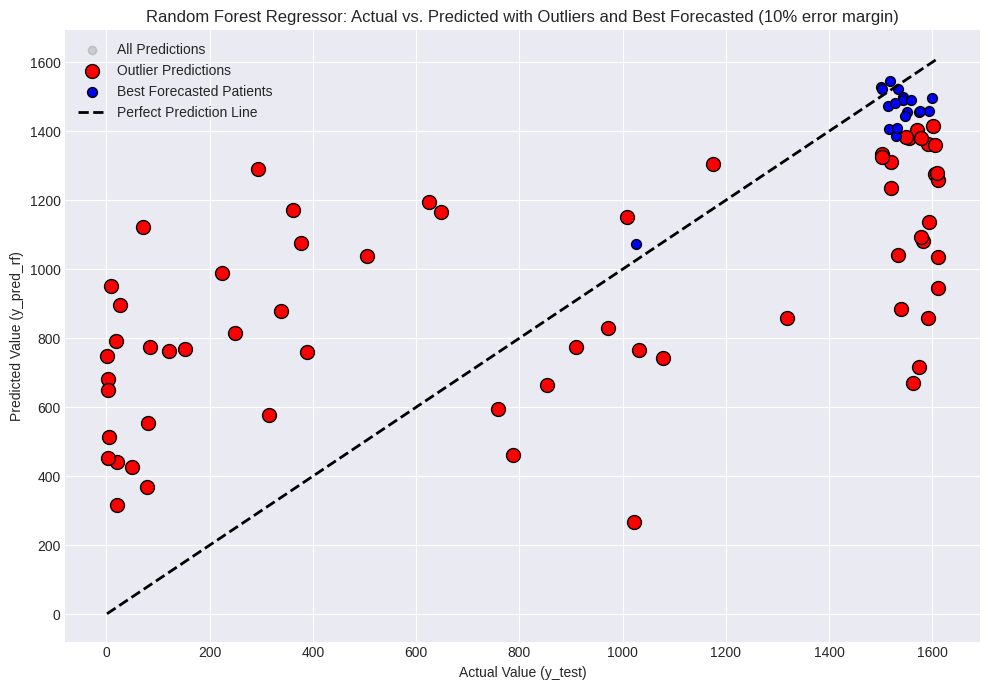


Number of outlier predictions: 63
Number of best forecasted patients: 19
Error margin for acceptable residuals: +/- 10% of actual value

--- Outlier Samples (Actual vs. Predicted) ---

--- Real Outlier Samples ---
    Actual  Predicted  Residual
0   1555.0   1379.430   175.570
1      9.0    952.674  -943.674
2    250.0    815.210  -565.210
3    505.0   1038.138  -533.138
4   1571.0   1402.252   168.748
5   1592.0   1362.938   229.062
6     20.0    441.980  -421.980
7   1079.0    742.344   336.656
8   1534.0   1041.790   492.210
9   1601.0   1413.788   187.212
10    50.0    425.758  -375.758
11  1549.0   1383.926   165.074
12  1612.0   1035.428   576.572
13    78.0    369.986  -291.986
14  1582.0   1082.324   499.676
15  1592.0    858.620   733.380
16    81.0    552.822  -471.822
17  1503.0   1334.344   168.656
18  1022.0    267.816   754.184
19  1032.0    765.302   266.698
20   224.0    987.932  -763.932
21   293.0   1291.498  -998.498
22    27.0    896.520  -869.520
23    70.0   1122

In [18]:
residuals = y_test - y_pred_rf

# Define 'best forecasted patients' based on a 10% error margin
# A prediction is 'best' if its absolute error is within 10% of the actual value.
error_margin = 0.10 # 10%

# Calculate lower and upper bounds for predictions to be considered 'best'
# Predicted value should be between (Actual * (1 - error_margin)) and (Actual * (1 + error_margin))
# This implies: Actual - (Actual * error_margin) <= Predicted <= Actual + (Actual * error_margin)
# Rearranging: -(Actual * error_margin) <= Predicted - Actual <= (Actual * error_margin)
# Or: -abs(Actual * error_margin) <= Residual <= abs(Actual * error_margin)

# For each actual value in y_test, define its acceptable residual range
acceptable_residual_lower_bound = -np.abs(y_test * error_margin)
acceptable_residual_upper_bound = np.abs(y_test * error_margin)

# Identify 'best forecasted patients' based on the new error margin
best_forecasted_mask = (residuals >= acceptable_residual_lower_bound) & (residuals <= acceptable_residual_upper_bound)

# Identify 'outlier predictions' as those NOT in the best forecasted group
outlier_mask = ~best_forecasted_mask

outlier_y_test = y_test[outlier_mask]
outlier_y_pred_rf = y_pred_rf[outlier_mask]

best_forecasted_y_test = y_test[best_forecasted_mask]
best_forecasted_y_pred_rf = y_pred_rf[best_forecasted_mask]

# Create DataFrame for best forecasted patients
best_forecasted_df = pd.DataFrame({
    'Actual': best_forecasted_y_test,
    'Predicted': best_forecasted_y_pred_rf,
    'Residual': residuals[best_forecasted_mask]
})

print("--- Typical Best Forecasted Patients (Residuals within 10% of Actual Value) ---")
display(best_forecasted_df.head())

# Plotting actual vs. predicted values with outliers and best forecasted patients highlighted
plt.figure(figsize=(10, 7))
plt.scatter(y_test, y_pred_rf, alpha=0.3, label='All Predictions', color='gray') # All points in gray
plt.scatter(outlier_y_test, outlier_y_pred_rf, color='red', s=100, label='Outlier Predictions', edgecolors='black')
plt.scatter(best_forecasted_y_test, best_forecasted_y_pred_rf, color='blue', s=50, label='Best Forecasted Patients', edgecolors='black')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Perfect Prediction Line')
plt.xlabel('Actual Value (y_test)')
plt.ylabel('Predicted Value (y_pred_rf)')
plt.title('Random Forest Regressor: Actual vs. Predicted with Outliers and Best Forecasted (10% error margin)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"\nNumber of outlier predictions: {len(outlier_y_test)}")
print(f"Number of best forecasted patients: {len(best_forecasted_y_test)}")
print(f"Error margin for acceptable residuals: +/- {error_margin*100:.0f}% of actual value")

print("\n--- Outlier Samples (Actual vs. Predicted) ---")
outlier_df = pd.DataFrame({'Actual': outlier_y_test, 'Predicted': outlier_y_pred_rf, 'Residual': residuals[outlier_mask]})

# Determine the threshold for original samples based on the length of the original `data` DataFrame
original_data_length = len(data)

# Create lists to store real and SMOTE-generated outlier samples
real_outliers = []
smote_outliers = []

for original_upsampled_index, row in outlier_df.iterrows():
    if original_upsampled_index < original_data_length:
        # This index corresponds to an original sample
        real_outliers.append(row.to_dict())
    else:
        # This index corresponds to a SMOTE-generated sample
        smote_outliers.append(row.to_dict())

print("\n--- Real Outlier Samples ---")
if real_outliers:
    print(pd.DataFrame(real_outliers).to_string())
else:
    print("No real outlier samples found.")

print("\n--- SMOTE-Generated Outlier Samples ---")
if smote_outliers:
    print(pd.DataFrame(smote_outliers).to_string())
else:
    print("No SMOTE-generated outlier samples found.")

In [19]:
real_outliers_df = pd.DataFrame(real_outliers)
real_outlier_indices = real_outliers_df.index

print("Real Outlier Samples from the original `data` DataFrame:")
display(data.loc[real_outlier_indices])

Real Outlier Samples from the original `data` DataFrame:


,doctor,time,age,af,dm,ckd,copd,insult,onco,severity,...,bmi,smoking,hb,leukoc,tromboc,t_chol,ldl,glu,crea,target
0,1,1152,79.000000,0,1,0,0,0,0,0,...,30.7,0,84.0,7.1,213.0,2.2,1.06,8.7,117.0,0
1,1,949,61.000000,1,1,0,0,0,1,1,...,34.0,0,166.0,9.4,225.0,5.8,3.61,4.4,94.0,0
2,1,1135,49.000000,0,0,0,0,0,0,1,...,23.0,1,150.0,10.5,208.0,7.4,5.09,3.9,74.0,0
3,2,1524,59.000000,0,0,0,0,0,0,1,...,26.5,1,142.0,5.1,58.0,5.3,3.30,4.2,86.0,0
4,2,1396,55.000000,0,0,0,0,0,0,1,...,29.0,1,151.0,7.7,305.0,7.3,5.07,4.3,96.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58,2,1528,51.000000,0,1,0,0,0,0,1,...,28.4,0,141.0,11.6,350.0,8.1,6.27,10.5,69.0,0
59,1,1142,53.000000,0,1,0,0,0,0,1,...,27.0,1,153.0,8.9,226.0,5.4,3.36,4.4,90.0,0
60,1,984,62.123288,1,1,0,0,0,0,1,...,28.0,0,167.0,9.6,161.0,5.4,3.21,6.0,92.0,0
61,2,1526,67.000000,0,0,0,0,0,0,1,...,26.6,0,131.0,7.4,214.0,7.2,4.40,5.3,60.0,0


Mean SHAP for llo: 0.3704


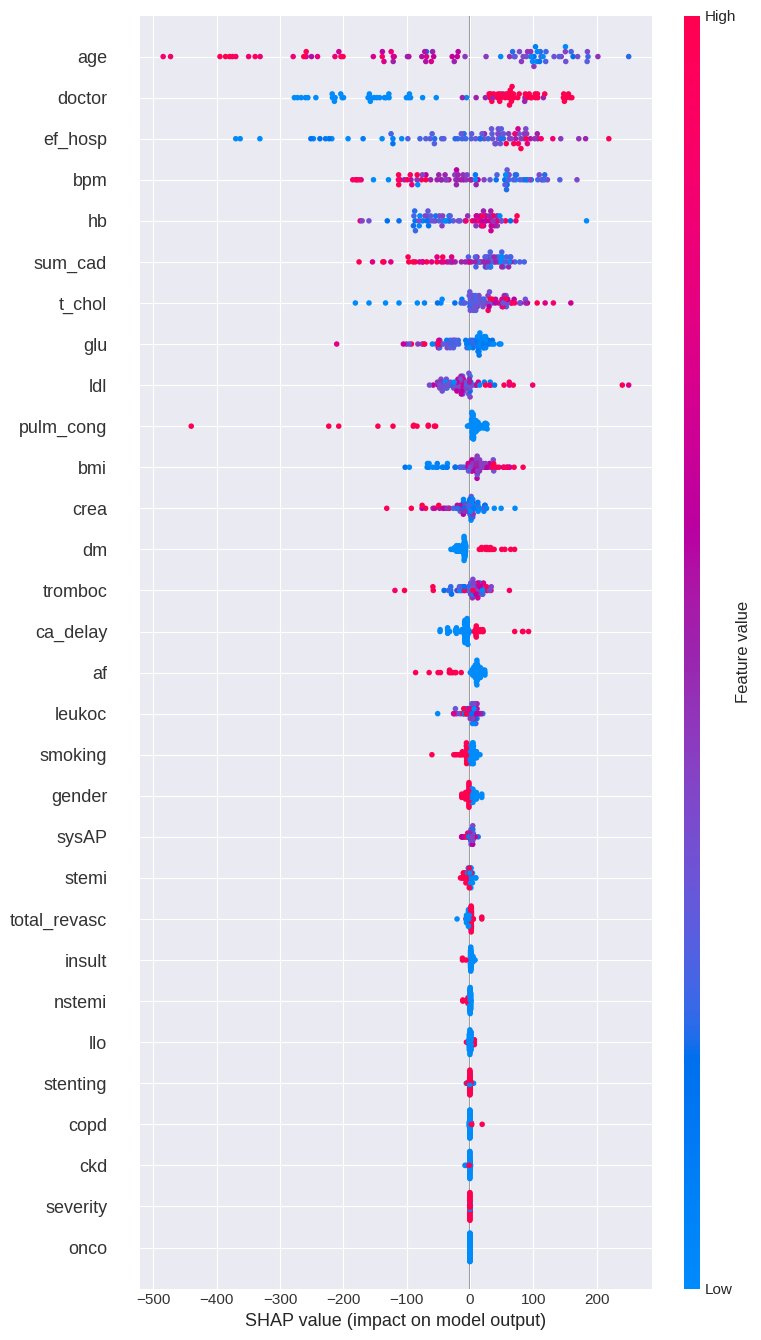

In [20]:
import shap
explainer = shap.TreeExplainer(gb_reg)
shap_values = explainer.shap_values(X_test_sc)

# Усреднённое влияние llo на вероятность result=1
llo_idx = list(X_balanced.columns).index('llo')
print(f"Mean SHAP for llo: {shap_values[:, llo_idx].mean():.4f}")
shap.summary_plot(shap_values, X_test_sc,
                  feature_names=X_balanced.columns,
                  max_display=len(X_balanced.columns)
                  )

# Оценка функции выживаемости

 ## 1. Cox Proportional Hazards

 Code implements a Cox Proportional Hazards (CoxPH) model, which is the most common semi-parametric model for survival analysis.

In [21]:
!pip install lifelines -q

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 11.5 MB/s eta 0:00:00


In [22]:
from lifelines import CoxPHFitter

In [23]:
# Reconstruct training DataFrame for CPH using the actual split data
# X_train_sc is a numpy array, y_train is a Series with original indices
# Get target values corresponding to y_train's indices from df_balanced
train_target_for_cph = df_balanced.loc[y_train.index, 'target']
cph_data_train_scaled = pd.DataFrame(X_train_sc, columns=original_features, index=y_train.index)
cph_data_train_scaled['time'] = y_train
cph_data_train_scaled['target'] = train_target_for_cph
cph_data_train_scaled = cph_data_train_scaled.dropna()

# Reconstruct testing DataFrame for CPH using the actual split data
# X_test_sc is a numpy array, y_test is a Series with original indices
# Get target values corresponding to y_test's indices from df_balanced
test_target_for_cph = df_balanced.loc[y_test.index, 'target']
cph_data_test_scaled = pd.DataFrame(X_test_sc, columns=original_features, index=y_test.index)
cph_data_test_scaled['time'] = y_test
cph_data_test_scaled['target'] = test_target_for_cph
cph_data_test_scaled = cph_data_test_scaled.dropna()

# Learning model with penalizer to address convergence issues
cph = CoxPHFitter(alpha=0.05, penalizer=0.1) # Added penalizer for regularization
cph.fit(cph_data_train_scaled, duration_col='time', event_col='target')

# Print summary
cph.print_summary()

# Evaluate survival function (Concordance Index) on TRAINING data
concordance_index = cph.score(cph_data_train_scaled, scoring_method="concordance_index")
print(f"\nConcordance Index on training set: {concordance_index:.4f}")

# Also calculate C-index on the test set for completeness, as cph_data_test_scaled is now correctly built.
concordance_index_test = cph.score(cph_data_test_scaled, scoring_method="concordance_index")
print(f"\nConcordance Index on test set: {concordance_index_test:.4f}")

<lifelines.CoxPHFitter: fitted with 325 total observations, 213 right-censored observations>
             duration col = 'time'
                event col = 'target'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 325
number of events observed = 112
   partial log-likelihood = -546.46
         time fit was run = 2026-07-09 11:08:43 UTC

---
              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                     
doctor       -0.35      0.70      0.09           -0.54           -0.17                0.59                0.84
age           0.34      1.40      0.11            0.13            0.55                1.14                1.73
af            0.16      1.18      0.08            0.00            0.32                1.00                1.38
dm           -0.25      0.77      0.09           -0.44           -0.07                0.64                0.93
ckd           0.14      1.15      0.09           -0.03            0.32                0.97                1.38
copd         -0.03      0.97      0.10           -0.22            0.17                0.80                1.18
insult        0.12      1.12      0.07           -0.03            0.26                0.97                1.30
onco         -0.11      0.90      0.14           -0.39            0.17                0.68                1.19
severity      0.11      1.12      0.13           -0.14            0.36                0.87                1.44
nstemi        0.03      1.03      0.11           -0.18            0.25                0.84                1.28
stemi         0.09      1.09      0.13           -0.16            0.34                0.85                1.41
llo          -0.08      0.92      0.09           -0.25            0.09                0.78                1.10
gender       -0.03      0.97      0.10           -0.23            0.18                0.79                1.19
ca_delay     -0.05      0.96      0.10           -0.24            0.15                0.79                1.16
sum_cad       0.34      1.40      0.10            0.15            0.53                1.16                1.70
stenting     -0.09      0.91      0.09           -0.28            0.09                0.76                1.09
total_revasc -0.03      0.97      0.10           -0.22            0.16                0.81                1.17
ef_hosp      -0.23      0.79      0.10           -0.43           -0.03                0.65                0.97
bpm           0.20      1.22      0.09            0.03            0.37                1.03                1.45
sysAP        -0.04      0.96      0.08           -0.20            0.12                0.82                1.13
pulm_cong     0.23      1.26      0.07            0.08            0.38                1.09                1.46
bmi          -0.06      0.94      0.09           -0.24            0.11                0.79                1.12
smoking       0.18      1.20      0.10           -0.02            0.39                0.98                1.47
hb           -0.07      0.93      0.09           -0.25            0.10                0.78                1.11
leukoc        0.02      1.02      0.09           -0.15            0.20                0.86                1.22
tromboc      -0.09      0.92      0.10           -0.28            0.11                0.76                1.11
t_chol       -0.24      0.79      0.13           -0.48            0.01                0.62                1.01
ldl          -0.09      0.91      0.13           -0.34            0.16                0.71                1.17
glu           0.27      1.32      0.09            0.09            0.46                1.09                1.58
crea         -0.01      0.99      0.07           -0.15            0.13                0.86                1.14

              cmp to     


Concordance Index on training set: 0.8399

Concordance Index on test set: 0.8141


The C-index ranges from 0.5 to 1.0:0.5: Indicates a completely random prediction, meaning the model has no predictive discrimination power.1.0: Indicates perfect concordance (the model flawlessly ranks all subjects based on their actual time-to-event).Example: A C-index of 0.78 means that for any two randomly selected subjects, the model will correctly identify which subject will experience the event earlier 78% of the time.

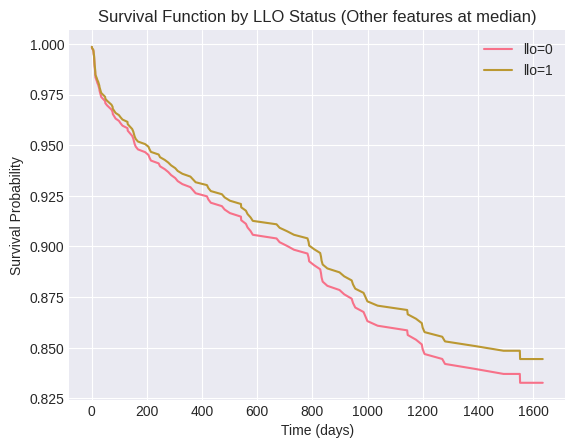

In [24]:
from lifelines import CoxPHFitter

# Create two hypothetical individuals for prediction:
# One with llo=0 and others features at their median
# One with llo=1 and others features at their median

# Use cph_data_train_scaled to get the median features, as this was the data used for fitting the CPH model.
# Drop 'time' and 'target' as they are not features for prediction.
median_data = cph_data_train_scaled.drop(columns=['time', 'target']).median().to_frame().T


# Individual with llo=0
pred_llo_0 = median_data.copy()
pred_llo_0['llo'] = 0

# Individual with llo=1
pred_llo_1 = median_data.copy()
pred_llo_1['llo'] = 1

# Concatenate for plotting
plot_data = pd.concat([pred_llo_0, pred_llo_1])
plot_data.index = ['llo=0', 'llo=1']

# Plot the survival function
cph.predict_survival_function(plot_data).plot()
plt.title('Survival Function by LLO Status (Other features at median)')
plt.xlabel('Time (days)')
plt.ylabel('Survival Probability')
plt.grid(True)
plt.show()

**Интерпретация графика функции выживаемости по статусу LLO:**

Survival function говорит о «накопленном успехе» (кто остался). Этот график функции выживаемости демонстрирует прогнозируемую вероятность выживания с течением времени для двух групп пациентов, различающихся только по статусу `llo` (факт получения лекарственного обеспечения):

*   **Красная линия (llo=0):** Представляет пациентов, которые **не** получают бесплатное лекарственное обеспечение. Кривая начинается со 100% выживаемости и постепенно снижается, показывая, как вероятность выживания уменьшается со временем.

*   **Желтая линия (llo=1):** Представляет пациентов, которые **получают** бесплатное лекарственное обеспечение.

**Вывод:** Визуально видно, что группа пациентов с `llo=1` (получающая льготное лекарственное обеспечение) имеет **более высокую вероятность выживания** по сравнению с группой `llo=0` (не получающей такое обеспечение). Это означает, что получение бесплатного лекарственного обеспечения после выписки ассоциируется с увеличением времени до наступления события (например, смерти) и, следовательно, с улучшением прогноза выживаемости, при условии, что другие факторы остаются на среднем уровне.

### feature importance

In [25]:



# Define a prediction wrapper function for the CoxPHFitter model.
# SHAP's KernelExplainer expects a function that takes a 2D numpy array
# and returns a 1D numpy array of predictions (e.g., expected survival time).
# The cph.predict_expectation method expects a DataFrame with named columns.
def cph_predict_expectation_wrapper(X_scaled_array):
    # Ensure the input array has the correct feature names and is a DataFrame
    # original_features should contain the names of all features in X_test_sc/X_train_sc
    X_df = pd.DataFrame(X_scaled_array, columns=original_features)
    # Predict expected lifetime
    return cph.predict_expectation(X_df).values

# For KernelExplainer, it's good practice to use a background dataset (e.g., a sample of X_train_sc).
# A smaller background dataset will run faster but might be less accurate.
# Let's use a sample of 100 observations from X_train_sc.
explainer_background = shap.sample(X_train_sc, 3)

# Initialize SHAP KernelExplainer with the wrapper function and background data
explainer = shap.KernelExplainer(cph_predict_expectation_wrapper, explainer_background)


In [26]:

# Calculate SHAP values for the test set. This can be computationally intensive.
# For demonstration, we might sample X_test_sc if it's very large.
# Using the full X_test_sc here as it's not excessively large (542 samples).
print("Calculating SHAP values for the CoxPH model's expected survival... This may take a while.")
shap_values_cph = explainer.shap_values(X_test_sc)

Calculating SHAP values for the CoxPH model's expected survival... This may take a while.


  0%|          | 0/82 [00:00<?, ?it/s]

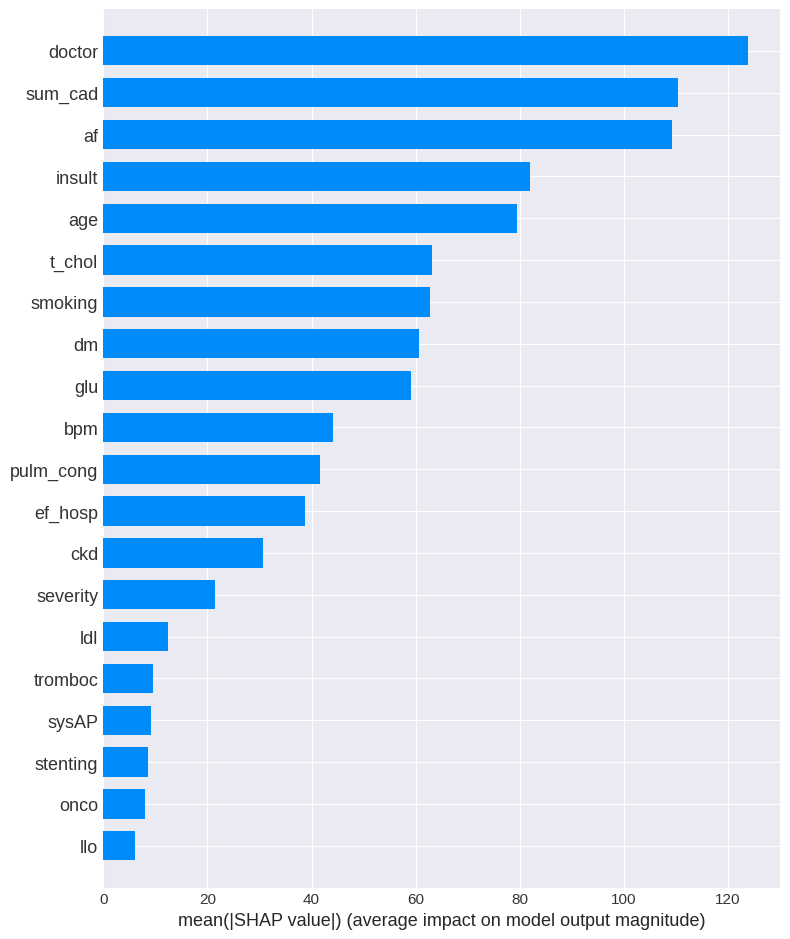

In [27]:

# Create a SHAP summary plot (bar) for the CoxPH model
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_cph, X_test_sc, feature_names=original_features, plot_type="bar")
#plt.title('Feature Importance (SHAP values) for CPH Expected Survival')
plt.show()

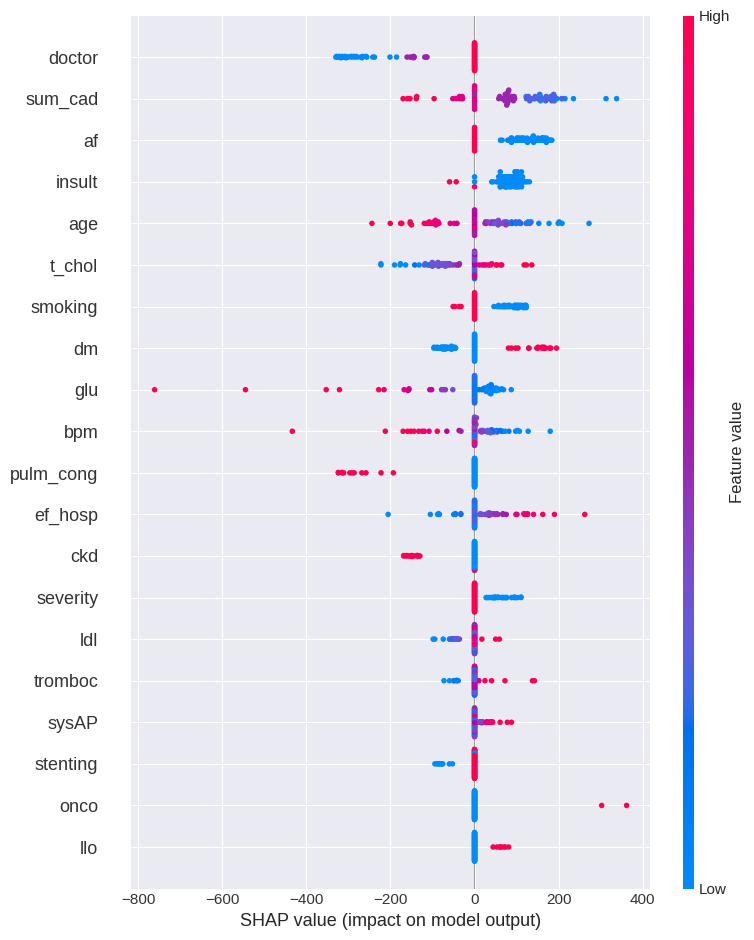

Interpretation of the SHAP summary plots for CoxPH Expected Survival:
- The bar plot shows the mean absolute SHAP value for each feature, indicating its overall importance to the CPH model's prediction of expected survival time.
- The dot plot provides more detail: 
  - Each dot represents a data point from the test set.
  - The x-axis is the SHAP value, indicating how much a feature's value contributed to pushing the CPH model's expected survival prediction higher or lower for that specific data point.
  - The color of the dot indicates the original value of the feature (red for high, blue for low), showing how feature values relate to their impact on expected survival.
  - For instance, features with positive SHAP values increase the expected survival, while those with negative SHAP values decrease it.


In [28]:
# Create a SHAP summary plot (dots) for the CoxPH model
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_cph, X_test_sc, feature_names=original_features)
#plt.title('Feature Impact (SHAP values) for CPH Expected Survival')
plt.show()

print("Interpretation of the SHAP summary plots for CoxPH Expected Survival:")
print("- The bar plot shows the mean absolute SHAP value for each feature, indicating its overall importance to the CPH model's prediction of expected survival time.")
print("- The dot plot provides more detail: ")
print("  - Each dot represents a data point from the test set.")
print("  - The x-axis is the SHAP value, indicating how much a feature's value contributed to pushing the CPH model's expected survival prediction higher or lower for that specific data point.")
print("  - The color of the dot indicates the original value of the feature (red for high, blue for low), showing how feature values relate to their impact on expected survival.")
print("  - For instance, features with positive SHAP values increase the expected survival, while those with negative SHAP values decrease it.")

## 2. Weibull

<lifelines.WeibullAFTFitter: fitted with 325 total observations, 213 right-censored observations>
             duration col = 'time'
                event col = 'target'
                penalizer = 0.1
   number of observations = 325
number of events observed = 112
           log-likelihood = -910.58
         time fit was run = 2026-07-09 11:32:24 UTC

---
                      coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                     
lambda_ af           -0.20      0.82      0.10           -0.39           -0.01                0.68                0.99
        age          -0.42      0.66      0.12           -0.65           -0.18                0.52                0.84
        bmi           0.09      1.10      0.11           -0.11            0.30                0.89                1.35
        bpm          -0.26      0.77      0.11           -0.47           -0.05                0.63                0.95
        ca_delay      0.08      1.08      0.11           -0.15            0.30                0.86                1.35
        ckd          -0.16      0.85      0.11           -0.37            0.05                0.69                1.05
        copd          0.02      1.02      0.12           -0.21            0.25                0.81                1.29
        crea         -0.02      0.98      0.09           -0.19            0.15                0.83                1.17
        dm            0.28      1.32      0.11            0.07            0.49                1.07                1.64
        doctor        0.42      1.53      0.11            0.21            0.64                1.23                1.89
        ef_hosp       0.32      1.37      0.12            0.08            0.55                1.08                1.73
        gender        0.04      1.04      0.12           -0.19            0.28                0.82                1.32
        glu          -0.35      0.70      0.11           -0.58           -0.13                0.56                0.88
        hb            0.09      1.10      0.10           -0.11            0.30                0.89                1.34
        insult       -0.15      0.86      0.09           -0.33            0.03                0.72                1.03
        ldl           0.14      1.15      0.13           -0.12            0.40                0.88                1.49
        leukoc       -0.03      0.97      0.10           -0.23            0.17                0.80                1.19
        llo           0.12      1.12      0.10           -0.09            0.32                0.92                1.37
        nstemi       -0.04      0.97      0.12           -0.27            0.20                0.76                1.22
        onco          0.11      1.12      0.15           -0.18            0.41                0.83                1.51
        pulm_cong    -0.30      0.74      0.09           -0.48           -0.11                0.62                0.89
        severity     -0.13      0.88      0.13           -0.39            0.14                0.68                1.15
        smoking      -0.18      0.84      0.12           -0.41            0.06                0.66                1.06
        stemi        -0.10      0.90      0.13           -0.37            0.16                0.69                1.17
        stenting      0.10      1.11      0.11           -0.11            0.32                0.89                1.37
        sum_cad      -0.40      0.67      0.11           -0.63           -0.18                0.53                0.83
        sysAP         0.04      1.05      0.10           -0.15            0.24                0.86                1.27
        t_chol        0.28      1.32      0.13            0.02            0.54                1.02                1.71
        total_revasc  0.04      1.04      0.11           -0.18         


AFT Concordance Index (on TRAINING data): 0.8372


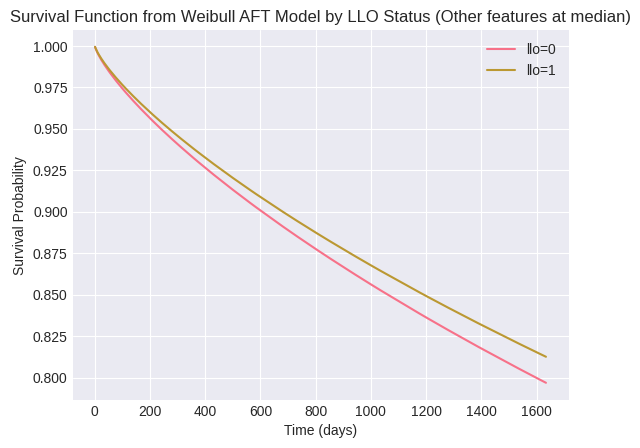


Interpretation of the plot:
This plot shows the predicted survival probability over time from the Weibull AFT model for two hypothetical individuals:
- One individual who does not receive LLO (llo=0), with other features set to their median training values.
- One individual who receives LLO (llo=1), with other features set to their median training values.
The curves illustrate how the survival probability changes over time for these two scenarios, highlighting the estimated effect of 'llo' status on survival according to the Weibull AFT model, assuming other factors are kept at their median levels.

Maximum predicted expected time (before clipping): 295602.73
Maximum predicted expected time (after clipping to 1634.0): 1634.00


In [50]:
from lifelines import WeibullAFTFitter

#---------USE THE SAME DATA AS IN A COX -------------------------------------------
train_target_for_cph = df_balanced.loc[y_train.index, 'target']
cph_data_train_scaled = pd.DataFrame(X_train_sc, columns=original_features, index=y_train.index)
cph_data_train_scaled['time'] = y_train
cph_data_train_scaled['target'] = train_target_for_cph
cph_data_train_scaled = cph_data_train_scaled.dropna()

# Reconstruct testing DataFrame for CPH using the actual split data
# X_test_sc is a numpy array, y_test is a Series with original indices
# Get target values corresponding to y_test's indices from df_balanced
test_target_for_cph = df_balanced.loc[y_test.index, 'target']
cph_data_test_scaled = pd.DataFrame(X_test_sc, columns=original_features, index=y_test.index)
cph_data_test_scaled['time'] = y_test
cph_data_test_scaled['target'] = test_target_for_cph
cph_data_test_scaled = cph_data_test_scaled.dropna()
#----------------------------------------------------



# Fit a Weibull AFT model
aft = WeibullAFTFitter(alpha=0.05, penalizer=0.1) # Added penalizer for regularization
aft.fit(cph_data_train_scaled, duration_col='time', event_col='target')

# Print summary
aft.print_summary()

# Evaluate Concordance Index on TRAINING data as the test set is fully censored.
c_index_aft = aft.score(cph_data_train_scaled, scoring_method="concordance_index")
print(f"\nAFT Concordance Index (on TRAINING data): {c_index_aft:.4f}")

# --- Plot Survival Functions ---
# Create two hypothetical individuals for prediction:
# One with llo=0 and others features at their median
# One with llo=1 and others features at their median

# Use cph_data_train_scaled to get the median features.
# Drop 'time' and 'target' as they are not features for prediction.
# 'cph_data_train_scaled' is appropriate here as it was used to fit the 'aft' model.
median_data = cph_data_train_scaled.drop(columns=['time', 'target']).median().to_frame().T

# Individual with llo=0
pred_llo_0 = median_data.copy()
pred_llo_0['llo'] = 0

# Individual with llo=1
pred_llo_1 = median_data.copy()
pred_llo_1['llo'] = 1

# Concatenate for plotting
plot_data = pd.concat([pred_llo_0, pred_llo_1])
plot_data.index = ['llo=0', 'llo=1']

# Plot the survival function using the Weibull AFT model (aft)
aft.predict_survival_function(plot_data).plot()
plt.title('Survival Function from Weibull AFT Model by LLO Status (Other features at median)')
plt.xlabel('Time (days)')
plt.ylabel('Survival Probability')
plt.grid(True)
plt.show()

print("\nInterpretation of the plot:")
print("This plot shows the predicted survival probability over time from the Weibull AFT model for two hypothetical individuals:")
print("- One individual who does not receive LLO (llo=0), with other features set to their median training values.")
print("- One individual who receives LLO (llo=1), with other features set to their median training values.")
print("The curves illustrate how the survival probability changes over time for these two scenarios, highlighting the estimated effect of 'llo' status on survival according to the Weibull AFT model, assuming other factors are kept at their median levels.")

# Get the maximum observed time from the training data
max_observed_time = time_train.max()

# Predict expected survival times for the entire training set
predicted_expected_times = aft.predict_expectation(cph_data_train_scaled.drop(columns=['time', 'target']))

# Apply clipping to ensure predicted expected times do not exceed the maximum observed time
predicted_expected_times_clipped = np.clip(predicted_expected_times, None, max_observed_time)

print(f"\nMaximum predicted expected time (before clipping): {predicted_expected_times.max():.2f}")
print(f"Maximum predicted expected time (after clipping to {max_observed_time}): {predicted_expected_times_clipped.max():.2f}")


## 3. Gradient Boosting

In [30]:
!pip install xgboost lifelines -q

In [31]:
from xgboost import XGBRegressor
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index

# --- 1. Prepare survival data ---
# Get target values corresponding to y_train's indices from df_balanced
train_target_for_xgb_calibration = df_balanced.loc[y_train.index, 'target']
event_train = train_target_for_xgb_calibration.astype(bool).values
time_train = y_train.astype(float).values

# Get target values corresponding to y_test's indices from df_balanced
test_target_for_xgb_calibration = df_balanced.loc[y_test.index, 'target']
event_test = test_target_for_xgb_calibration.astype(bool).values
time_test = y_test.astype(float).values

# XGBoost survival:cox expects:
# positive time = observed event
# negative time = censored
y_train_xgb = np.where(event_train, time_train, -time_train)

# --- 2. Train Gradient Boosting Cox model ---
xgb_surv = XGBRegressor(
    objective="survival:cox",
    eval_metric="cox-nloglik",
    n_estimators=300,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.8,
    colsample_bynode=0.8,
    random_state=42
)

xgb_surv.fit(X_train_sc, y_train_xgb)

# --- 3. Predict risk scores ---
# Predict risk scores on training data for C-index calculation
risk_train = xgb_surv.predict(X_train_sc)

# C-index using lifelines on TRAINING data
# risk_train: higher = higher risk = shorter survival
# concordance_index expects higher score = longer survival, so use -risk_train
from lifelines.utils import concordance_index

c_index_xgb = concordance_index(
    time_train, # Use training times
    -risk_train, # Use negative risk scores from training predictions
    event_train # Use training events
)

print(f"\nXGBoost Cox Survival C-Index (on TRAINING data): {c_index_xgb:.4f}")

# --- 4. Estimate baseline survival using CoxPH with XGB risk as one covariate ---
cox_df_train = pd.DataFrame({
    "time": time_train,
    "event": event_train.astype(int),
    "xgb_risk": xgb_surv.predict(X_train_sc)
})

cox_calibrator = CoxPHFitter(alpha=0.05)
cox_calibrator.fit(
    cox_df_train,
    duration_col="time",
    event_col="event"
)


XGBoost Cox Survival C-Index (on TRAINING data): 0.9653


<lifelines.CoxPHFitter: fitted with 325 total observations, 213 right-censored observations>

<Figure size 1000x600 with 0 Axes>

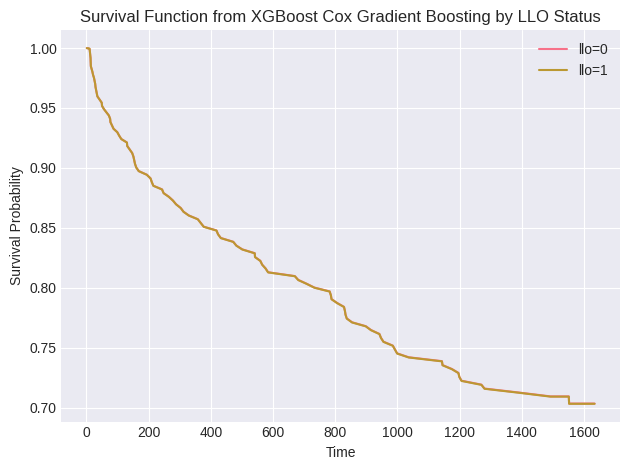


Interpretation of the plot:
This plot shows the predicted survival probability over time from the XGBoost Cox Gradient Boosting model for two hypothetical individuals:
- One individual who does not receive LLO (llo=0), with other features set to their median training values.
- One individual who receives LLO (llo=1), with other features set to their median training values.
The curves illustrate how the survival probability changes over time for these two scenarios, highlighting the estimated effect of 'llo' status on survival according to the XGBoost Cox model, assuming other factors are kept at their median levels.


In [32]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Get median features from the scaled training data used for CPH, excluding time and target
# original_features contains the feature names for X_train_sc
median_features_scaled = pd.DataFrame(X_train_sc, columns=original_features).median().to_frame().T

# Create hypothetical individuals with llo=0 and llo=1, other features at median
pred_llo_0_scaled = median_features_scaled.copy()
pred_llo_0_scaled['llo'] = (0 - scaler.mean_[original_features.index('llo')]) / scaler.scale_[original_features.index('llo')] # Scale llo=0

pred_llo_1_scaled = median_features_scaled.copy()
pred_llo_1_scaled['llo'] = (1 - scaler.mean_[original_features.index('llo')]) / scaler.scale_[original_features.index('llo')] # Scale llo=1

# Convert to numpy arrays for xgb_surv prediction if it expects it, or ensure DataFrame structure is compatible
# xgb_surv.predict expects a 2D array, so we can convert the single-row DataFrames to numpy
X_pred_llo_0_xgb = pred_llo_0_scaled.values
X_pred_llo_1_xgb = pred_llo_1_scaled.values

# Predict risk scores using the trained XGBoost model
risk_llo_0 = xgb_surv.predict(X_pred_llo_0_xgb)
risk_llo_1 = xgb_surv.predict(X_pred_llo_1_xgb)

# Create a DataFrame for the Cox calibrator
# The cox_calibrator was fit on a DataFrame with a single column 'xgb_risk'
risk_data_for_calibrator = pd.DataFrame({
    'xgb_risk': [risk_llo_0[0], risk_llo_1[0]]
}, index=['llo=0', 'llo=1'])

# Predict survival functions using the cox_calibrator
surv_funcs_xgb = cox_calibrator.predict_survival_function(risk_data_for_calibrator)

# Plot the survival functions
plt.figure(figsize=(10, 6))
surv_funcs_xgb.plot()
plt.title('Survival Function from XGBoost Cox Gradient Boosting by LLO Status')
plt.xlabel('Time')
plt.ylabel('Survival Probability')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nInterpretation of the plot:")
print("This plot shows the predicted survival probability over time from the XGBoost Cox Gradient Boosting model for two hypothetical individuals:")
print("- One individual who does not receive LLO (llo=0), with other features set to their median training values.")
print("- One individual who receives LLO (llo=1), with other features set to their median training values.")
print("The curves illustrate how the survival probability changes over time for these two scenarios, highlighting the estimated effect of 'llo' status on survival according to the XGBoost Cox model, assuming other factors are kept at their median levels.")

# Neural Network approach LifeTime prediction

## Neural Network approach

Training the Neural Network for event prediction...
Neural Network training complete.
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step

Neural Network Event Prediction C-Index (on TRAINING data): 0.8806
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


<Figure size 1000x600 with 0 Axes>

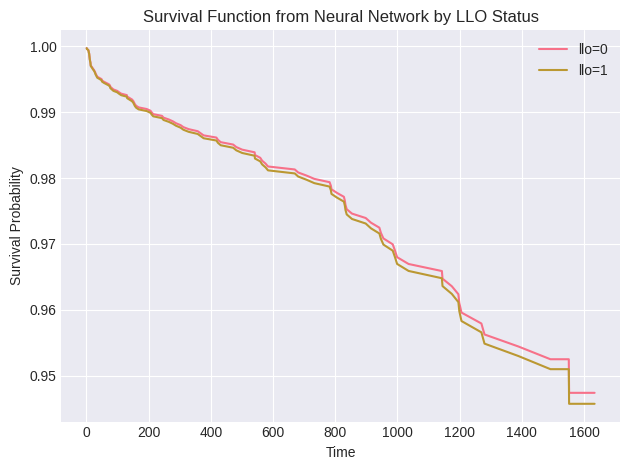


Interpretation of the plot:
- This plot illustrates the predicted survival probability over time from the Neural Network model for two hypothetical individuals:
- One individual who does not receive LLO (llo=0), with other features set to their median training values.
- One individual who receives LLO (llo=1), with other features set to their median training values.
- The curves demonstrate how the survival probability changes over time for these two scenarios, highlighting the estimated effect of 'llo' status on survival according to the Neural Network model (calibrated by CoxPH), assuming other factors are kept at their median levels.


In [33]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Reconstruct training DataFrame for CPH using the actual split data
# This block is from the user's provided context to ensure consistent data usage
train_target_for_cph = df_balanced.loc[y_train.index, 'target']
cph_data_train_scaled = pd.DataFrame(X_train_sc, columns=original_features, index=y_train.index)
cph_data_train_scaled['time'] = y_train
cph_data_train_scaled['target'] = train_target_for_cph
cph_data_train_scaled = cph_data_train_scaled.dropna()

# Reconstruct testing DataFrame for CPH using the actual split data
test_target_for_cph = df_balanced.loc[y_test.index, 'target']
cph_data_test_scaled = pd.DataFrame(X_test_sc, columns=original_features, index=y_test.index)
cph_data_test_scaled['time'] = y_test
cph_data_test_scaled['target'] = test_target_for_cph
cph_data_test_scaled = cph_data_test_scaled.dropna()


# --- 1. Define the Neural Network Model for Event (Target) Prediction (Binary Classification) ---
def build_nn_model_classification(input_shape):
    model = keras.Sequential([
        layers.Input(shape=(input_shape,)),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid') # Output a single probability (0 to 1)
    ])
    return model

nn_model_classification = build_nn_model_classification(X_train_sc.shape[1])

# --- 2. Compile the model (for binary classification) ---
nn_model_classification.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy']) # Using binary crossentropy for event prediction

# --- 3. Train the Neural Network to predict 'event_train' ---
print("Training the Neural Network for event prediction...")
history = nn_model_classification.fit(
    X_train_sc,
    event_train, # Train to predict the event (0 or 1)
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)
print("Neural Network training complete.")

# --- 4. Predict Event Probabilities ---
# Predict probabilities of the event (target=1) for the training set
# These probabilities will serve as the 'risk' score for the Cox calibrator
event_prob_nn_train = nn_model_classification.predict(X_train_sc).flatten()

# --- 5. Evaluate C-index ---
# lifelines.concordance_index expects higher scores to mean LONGER survival.
# Our NN predicts probability of event (death), so higher prob = higher risk = shorter survival.
# Therefore, we use -event_prob_nn_train for concordance_index calculation.
c_index_nn = concordance_index(
    time_train,
    -event_prob_nn_train, # Use negative event probability as risk score
    event_train
)
print(f"\nNeural Network Event Prediction C-Index (on TRAINING data): {c_index_nn:.4f}")

# --- 6. Estimate baseline survival using CoxPH with NN's event probabilities as a covariate ---
cox_df_train_nn = pd.DataFrame({
    "time": time_train,
    "event": event_train.astype(int),
    "nn_event_probability": event_prob_nn_train # Use predicted event probability as a covariate
})

cox_calibrator_nn = CoxPHFitter(alpha=0.05)
cox_calibrator_nn.fit(
    cox_df_train_nn,
    duration_col="time",
    event_col="event"
)

# --- 7. Plot Survival Functions for selected LLO values ---
# Get median features from the scaled training data, using original_features for column names
median_features_scaled = pd.DataFrame(X_train_sc, columns=original_features).median().to_frame().T

# Get the index of the 'llo' feature from the original feature names
llo_feature_idx = original_features.index('llo')

# Create hypothetical individuals with llo=0 and llo=1, with other features at median
pred_llo_0_scaled = median_features_scaled.copy()
pred_llo_1_scaled = median_features_scaled.copy()

# Scale llo=0 and llo=1 using the original scaler
# Ensure the 'scaler' object is available from previous cells and has fit the data
if 'scaler' in locals() and hasattr(scaler, 'mean_') and hasattr(scaler, 'scale_'):
    pred_llo_0_scaled['llo'] = (0 - scaler.mean_[llo_feature_idx]) / scaler.scale_[llo_feature_idx]
    pred_llo_1_scaled['llo'] = (1 - scaler.mean_[llo_feature_idx]) / scaler.scale_[llo_feature_idx]
else:
    print("Warning: 'scaler' object not found or incomplete. Using unscaled 'llo' values for prediction.")
    pred_llo_0_scaled['llo'] = 0
    pred_llo_1_scaled['llo'] = 1

# Predict the event probability for these hypothetical individuals using the trained NN
# Convert to numpy array for NN prediction
nn_event_prob_llo_0 = nn_model_classification.predict(pred_llo_0_scaled.values).flatten()
nn_event_prob_llo_1 = nn_model_classification.predict(pred_llo_1_scaled.values).flatten()

# Create a DataFrame for the Cox calibrator, using the NN's event probabilities
risk_data_for_calibrator_nn = pd.DataFrame({
    'nn_event_probability': [nn_event_prob_llo_0[0], nn_event_prob_llo_1[0]]
}, index=['llo=0', 'llo=1'])

# Predict survival functions using the calibrated Cox model
surv_funcs_nn = cox_calibrator_nn.predict_survival_function(risk_data_for_calibrator_nn)

# Plot the survival functions
plt.figure(figsize=(10, 6))
surv_funcs_nn.plot()
plt.title('Survival Function from Neural Network by LLO Status')
plt.xlabel('Time')
plt.ylabel('Survival Probability')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nInterpretation of the plot:")
print("- This plot illustrates the predicted survival probability over time from the Neural Network model for two hypothetical individuals:")
print("- One individual who does not receive LLO (llo=0), with other features set to their median training values.")
print("- One individual who receives LLO (llo=1), with other features set to their median training values.")
print("- The curves demonstrate how the survival probability changes over time for these two scenarios, highlighting the estimated effect of 'llo' status on survival according to the Neural Network model (calibrated by CoxPH), assuming other factors are kept at their median levels.")

## Reservoir Network

Training Reservoir Neural Network for event (target) prediction...
Reservoir Network training complete.

Reservoir Network Event Prediction C-Index (on TRAINING data): 0.9177


<Figure size 1000x600 with 0 Axes>

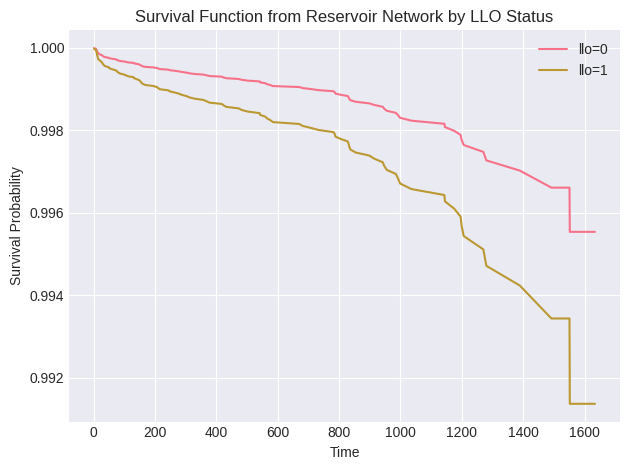


Interpretation of the plot:
- This plot illustrates the predicted survival probability over time from the Reservoir Neural Network model
  for two hypothetical individuals:
- One individual who does not receive LLO (llo=0), with other features set to their median training values.
- One individual who receives LLO (llo=1), with other features set to their median training values.
- The curves demonstrate how the survival probability changes over time for these scenarios,
  highlighting the estimated effect of 'llo' status on survival according to the Reservoir Network
  (calibrated by CoxPH), assuming other factors are kept at their median levels.


In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression # Changed from Ridge
from sklearn.base import BaseEstimator, ClassifierMixin # Changed from RegressorMixin
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index

# ==========================================
# 1. Data Preparation (User provided)
# ==========================================
# This block is from the user's provided context to ensure consistent data usage
train_target_for_cph = df_balanced.loc[y_train.index, 'target']
cph_data_train_scaled = pd.DataFrame(X_train_sc, columns=original_features, index=y_train.index)
cph_data_train_scaled['time'] = y_train
cph_data_train_scaled['target'] = train_target_for_cph
cph_data_train_scaled = cph_data_train_scaled.dropna()

# Reconstruct testing DataFrame for CPH using the actual split data
test_target_for_cph = df_balanced.loc[y_test.index, 'target']
cph_data_test_scaled = pd.DataFrame(X_test_sc, columns=original_features, index=y_test.index)
cph_data_test_scaled['time'] = y_test
cph_data_test_scaled['target'] = test_target_for_cph
cph_data_test_scaled = cph_data_test_scaled.dropna()

# Ensure event_train and time_train are correctly defined from cph_data_train_scaled
event_train = cph_data_train_scaled['target'].astype(bool).values
time_train = cph_data_train_scaled['time'].astype(float).values

# Ensure event_test and time_test are correctly defined from cph_data_test_scaled
event_test = cph_data_test_scaled['target'].astype(bool).values
time_test = cph_data_test_scaled['time'].astype(float).values


# ==========================================
# 2. Reservoir Neural Network Definition (Modified for Classification)
# ==========================================
class ReservoirNetwork(BaseEstimator, ClassifierMixin): # Changed to ClassifierMixin
    """
    A Reservoir Neural Network (Echo State Network adapted for tabular data) for classification.

    Uses a high-dimensional random projection (Reservoir) to map input features
    into a non-linear space, followed by a Logistic Regression readout layer
    for binary classification (predicting 'target' event status).
    """
    def __init__(self, n_reservoir=1000, readout_solver='liblinear', random_state=42):
        self.n_reservoir = n_reservoir
        self.readout_solver = readout_solver # For LogisticRegression
        self.random_state = random_state
        self.W_in = None
        self.readout = None

    def _init_reservoir_weights(self, n_features):
        np.random.seed(self.random_state)
        W_in = np.random.normal(0, 1, (n_features, self.n_reservoir))
        W_in /= np.sqrt(np.sum(W_in**2, axis=0, keepdims=True) + 1e-8)
        return W_in

    def _compute_states(self, X):
        return np.tanh(X @ self.W_in)

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.W_in = self._init_reservoir_weights(n_features)

        R_train = self._compute_states(X)

        # Train the readout layer (Logistic Regression) to predict the target event
        self.readout = LogisticRegression(solver=self.readout_solver, random_state=self.random_state)
        self.readout.fit(R_train, y)
        return self

    def predict_proba(self, X):
        R_test = self._compute_states(X)
        return self.readout.predict_proba(R_test)[:, 1] # Return probabilities for the positive class (event=1)

# ==========================================
# 3. Train Reservoir Network for 'target' prediction
# ==========================================
print("Training Reservoir Neural Network for event (target) prediction...")
rn_model_classification = ReservoirNetwork(n_reservoir=2000, random_state=42)
rn_model_classification.fit(X_train_sc, event_train) # Train on event_train (0 or 1)
print("Reservoir Network training complete.")


# ==========================================
# 4. Predict Event Probabilities and Evaluate C-index
# ==========================================
# Predict event probabilities for the training set
event_prob_rn_train = rn_model_classification.predict_proba(X_train_sc).flatten()

# lifelines.concordance_index expects higher scores to mean LONGER survival.
# Our RN predicts probability of event (death), so higher prob = higher risk = shorter survival.
# Therefore, we use -event_prob_rn_train for concordance_index calculation.
c_index_rn = concordance_index(
    time_train,
    -event_prob_rn_train, # Use negative event probability as risk score
    event_train
)
print(f"\nReservoir Network Event Prediction C-Index (on TRAINING data): {c_index_rn:.4f}")


# ==========================================
# 5. Estimate Baseline Survival using CoxPH with RN's event probabilities as a covariate
# ==========================================
cox_df_train_rn = pd.DataFrame({
    "time": time_train,
    "event": event_train.astype(int),
    "rn_event_probability": event_prob_rn_train # Use predicted event probability as a covariate
})

cox_calibrator_rn = CoxPHFitter(alpha=0.05)
cox_calibrator_rn.fit(
    cox_df_train_rn,
    duration_col="time",
    event_col="event"
)


# ==========================================
# 6. Plot Survival Functions for LLO Status
# ==========================================
# Get median features from the scaled training data, using original_features for column names
median_features_scaled = pd.DataFrame(X_train_sc, columns=original_features).median().to_frame().T

# Get the index of the 'llo' feature from the original feature names
llo_feature_idx = original_features.index('llo')

# Create hypothetical individuals with llo=0 and llo=1, with other features at median
pred_llo_0_scaled = median_features_scaled.copy()
pred_llo_1_scaled = median_features_scaled.copy()

# Scale llo=0 and llo=1 using the original scaler
# Ensure the 'scaler' object is available from previous cells and has fit the data
if 'scaler' in locals() and hasattr(scaler, 'mean_') and hasattr(scaler, 'scale_'):
    pred_llo_0_scaled['llo'] = (0 - scaler.mean_[llo_feature_idx]) / scaler.scale_[llo_feature_idx]
    pred_llo_1_scaled['llo'] = (1 - scaler.mean_[llo_feature_idx]) / scaler.scale_[llo_feature_idx]
else:
    print("Warning: 'scaler' object not found or incomplete. Using unscaled 'llo' values for prediction.")
    pred_llo_0_scaled['llo'] = 0
    pred_llo_1_scaled['llo'] = 1

# Predict the event probability for these hypothetical individuals using the trained Reservoir Network
# Convert to numpy array for RN prediction
rn_event_prob_llo_0 = rn_model_classification.predict_proba(pred_llo_0_scaled.values).flatten()
rn_event_prob_llo_1 = rn_model_classification.predict_proba(pred_llo_1_scaled.values).flatten()

# Create a DataFrame for the Cox calibrator, using the RN's event probabilities
risk_data_for_calibrator_rn = pd.DataFrame({
    'rn_event_probability': [rn_event_prob_llo_0[0], rn_event_prob_llo_1[0]]
}, index=['llo=0', 'llo=1'])

# Predict survival functions using the calibrated Cox model
surv_funcs_rn = cox_calibrator_rn.predict_survival_function(risk_data_for_calibrator_rn)

# Plot the survival functions
plt.figure(figsize=(10, 6))
surv_funcs_rn.plot()
plt.title('Survival Function from Reservoir Network by LLO Status')
plt.xlabel('Time')
plt.ylabel('Survival Probability')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nInterpretation of the plot:")
print("- This plot illustrates the predicted survival probability over time from the Reservoir Neural Network model")
print("  for two hypothetical individuals:")
print("- One individual who does not receive LLO (llo=0), with other features set to their median training values.")
print("- One individual who receives LLO (llo=1), with other features set to their median training values.")
print("- The curves demonstrate how the survival probability changes over time for these scenarios,")
print("  highlighting the estimated effect of 'llo' status on survival according to the Reservoir Network")
print("  (calibrated by CoxPH), assuming other factors are kept at their median levels.")

# Methods comparison

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
### Model Comparison: Concordance Index (C-index on TRAINING Data)

                                 C-index
Model                                   
Cox Proportional Hazards          0.8399
Weibull AFT                       0.8372
XGBoost Cox (Gradient Boosting)   0.9653
Neural Network (NN) Survival      0.8806
Reservoir Network (RN) Survival   0.9177
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


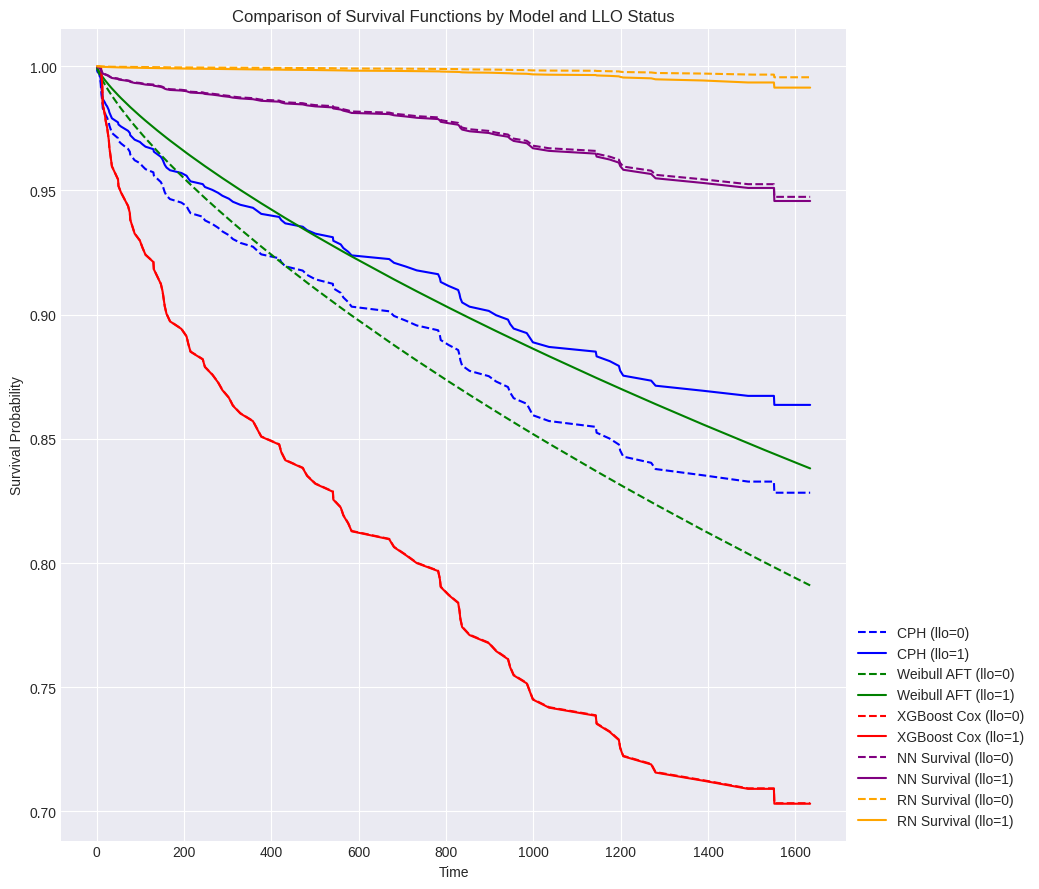


Interpretation of the comparison plot:
- This plot visualizes the predicted survival probabilities over time for a hypothetical individual with LLO=0 (dashed lines) and LLO=1 (solid lines) across all five survival models (CPH, Weibull AFT, XGBoost Cox, NN Survival, and RN Survival).
- Please note that the C-index values presented above are calculated on the training data, as the test set was specifically designed to contain only censored events, making a meaningful out-of-sample C-index impossible.
- Each color represents a different model (e.g., blue for CPH, green for Weibull AFT, red for XGBoost Cox, purple for NN Survival, orange for RN Survival).
- Comparing curves across different models allows us to see how their predictions for survival probabilities differ and where there is more or less agreement in their prognostic capabilities.


In [51]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from lifelines.utils import concordance_index

# Calculate C-indices on the TRAINING set, as the TEST set (event_test) is fully censored
# CPH Model C-index (on training data)
# Ensure 'cph' is defined. If this cell is run after a kernel restart, 'cph' might be undefined.
# It's assumed previous cells defining cph, aft, xgb_surv, cox_calibrator, nn_model_classification, cox_calibrator_nn, rn_model_classification, cox_calibrator_rn are executed.
concordance_index_cph = cph.score(cph_data_train_scaled, scoring_method="concordance_index")

# Weibull AFT Model C-index (on training data)
c_index_aft = aft.score(cph_data_train_scaled, scoring_method="concordance_index")

# XGBoost Cox Model C-index (on training data)
risk_train_xgb = xgb_surv.predict(X_train_sc)
c_index_xgb = concordance_index(time_train, -risk_train_xgb, event_train)

# Neural Network C-index (on training data)
# Corrected model name from 'nn_model' to 'nn_model_classification'
# Corrected to use negative of event probability for C-index calculation
event_prob_nn_train_for_cindex = nn_model_classification.predict(X_train_sc).flatten()
c_index_nn_recalculated = concordance_index(time_train, -event_prob_nn_train_for_cindex, event_train)

# Reservoir Network C-index (on training data)
# Corrected model name from 'rn_model' to 'rn_model_classification'
# Corrected to use negative of event probability for C-index calculation
event_prob_rn_train_for_cindex = rn_model_classification.predict_proba(X_train_sc).flatten()
c_index_rn = concordance_index(time_train, -event_prob_rn_train_for_cindex, event_train)

# 1. Evaluate accuracy (C-index) and plot differences
print("### Model Comparison: Concordance Index (C-index on TRAINING Data)\n")
c_index_summary = pd.DataFrame({
    'Model': ['Cox Proportional Hazards', 'Weibull AFT', 'XGBoost Cox (Gradient Boosting)', 'Neural Network (NN) Survival', 'Reservoir Network (RN) Survival'],
    'C-index': [concordance_index_cph, c_index_aft, c_index_xgb, c_index_nn_recalculated, c_index_rn]
}).set_index('Model')

print(c_index_summary.to_string(float_format="%.4f"))

# Create hypothetical individuals for prediction (LLO=0 and LLO=1) based on median features
# Use cph_data_train_scaled to get the median features, as this was the data used for fitting CPH and Weibull models.
# Drop 'time' and 'target' as they are not features for prediction.
median_features_scaled = cph_data_train_scaled.drop(columns=['time', 'target']).median().to_frame().T

# --- Scaling 'llo' feature for hypothetical individuals ---
llo_feature_idx = original_features.index('llo') # Ensure original_features is available

pred_llo_0_scaled = median_features_scaled.copy()
pred_llo_1_scaled = median_features_scaled.copy()

if 'scaler' in locals() and hasattr(scaler, 'mean_') and hasattr(scaler, 'scale_'):
    pred_llo_0_scaled['llo'] = (0 - scaler.mean_[llo_feature_idx]) / scaler.scale_[llo_feature_idx]
    pred_llo_1_scaled['llo'] = (1 - scaler.mean_[llo_feature_idx]) / scaler.scale_[llo_feature_idx]
else:
    print("Warning: 'scaler' object not found or incomplete. Using unscaled 'llo' values for prediction.")
    pred_llo_0_scaled['llo'] = 0
    pred_llo_1_scaled['llo'] = 1


# --- CPH and Weibull AFT predictions ---
# These models directly use the scaled features
sf_cph_llo_0 = cph.predict_survival_function(pred_llo_0_scaled)
sf_cph_llo_1 = cph.predict_survival_function(pred_llo_1_scaled)

sf_aft_llo_0 = aft.predict_survival_function(pred_llo_0_scaled)
sf_aft_llo_1 = aft.predict_survival_function(pred_llo_1_scaled)

# --- XGBoost Cox predictions ---
# Predict risk scores for hypothetical individuals using xgb_surv model
# (Note: xgb_surv expects scaled features)
risk_llo_0_xgb = xgb_surv.predict(pred_llo_0_scaled.values)
risk_llo_1_xgb = xgb_surv.predict(pred_llo_1_scaled.values)

# Create DataFrame for the Cox calibrator
risk_data_for_calibrator_xgb = pd.DataFrame({
    'xgb_risk': [risk_llo_0_xgb[0], risk_llo_1_xgb[0]]
}, index=['llo=0', 'llo=1'])

sf_xgb_llo_0 = cox_calibrator.predict_survival_function(risk_data_for_calibrator_xgb.loc[['llo=0']])
sf_xgb_llo_1 = cox_calibrator.predict_survival_function(risk_data_for_calibrator_xgb.loc[['llo=1']])

# --- Neural Network predictions ---
# Predict event probability for hypothetical individuals using nn_model_classification
# (Note: nn_model_classification expects scaled features)
nn_event_prob_llo_0 = nn_model_classification.predict(pred_llo_0_scaled.values).flatten()
nn_event_prob_llo_1 = nn_model_classification.predict(pred_llo_1_scaled.values).flatten()

# Create DataFrame for the Cox calibrator
# Corrected column name to 'nn_event_probability'
risk_data_for_calibrator_nn_plot = pd.DataFrame({
    'nn_event_probability': [nn_event_prob_llo_0[0], nn_event_prob_llo_1[0]]
}, index=['llo=0', 'llo=1'])

sf_nn_llo_0 = cox_calibrator_nn.predict_survival_function(risk_data_for_calibrator_nn_plot.loc[['llo=0']])
sf_nn_llo_1 = cox_calibrator_nn.predict_survival_function(risk_data_for_calibrator_nn_plot.loc[['llo=1']])

# --- Reservoir Network predictions ---
# Predict event probability for hypothetical individuals using rn_model_classification
# (Note: rn_model_classification expects scaled features)
rn_event_prob_llo_0 = rn_model_classification.predict_proba(pred_llo_0_scaled.values).flatten()
rn_event_prob_llo_1 = rn_model_classification.predict_proba(pred_llo_1_scaled.values).flatten()

# Create DataFrame for the Cox calibrator
# Corrected column name to 'rn_event_probability'
risk_data_for_calibrator_rn_plot = pd.DataFrame({
    'rn_event_probability': [rn_event_prob_llo_0[0], rn_event_prob_llo_1[0]]
}, index=['llo=0', 'llo=1'])

sf_rn_llo_0 = cox_calibrator_rn.predict_survival_function(risk_data_for_calibrator_rn_plot.loc[['llo=0']])
sf_rn_llo_1 = cox_calibrator_rn.predict_survival_function(risk_data_for_calibrator_rn_plot.loc[['llo=1']])


# Plotting the survival functions
plt.figure(figsize=(14, 9)) # Slightly larger figure for clarity

# CPH
plt.plot(sf_cph_llo_0.index, sf_cph_llo_0, label='CPH (llo=0)', linestyle='--', color='blue')
plt.plot(sf_cph_llo_1.index, sf_cph_llo_1, label='CPH (llo=1)', linestyle='-', color='blue')

# Weibull AFT
plt.plot(sf_aft_llo_0.index, sf_aft_llo_0, label='Weibull AFT (llo=0)', linestyle='--', color='green')
plt.plot(sf_aft_llo_1.index, sf_aft_llo_1, label='Weibull AFT (llo=1)', linestyle='-', color='green')

# XGBoost Cox
plt.plot(sf_xgb_llo_0.index, sf_xgb_llo_0, label='XGBoost Cox (llo=0)', linestyle='--', color='red')
plt.plot(sf_xgb_llo_1.index, sf_xgb_llo_1, label='XGBoost Cox (llo=1)', linestyle='-', color='red')

# Neural Network
plt.plot(sf_nn_llo_0.index, sf_nn_llo_0, label='NN Survival (llo=0)', linestyle='--', color='purple')
plt.plot(sf_nn_llo_1.index, sf_nn_llo_1, label='NN Survival (llo=1)', linestyle='-', color='purple')

# Reservoir Network (added)
plt.plot(sf_rn_llo_0.index, sf_rn_llo_0, label='RN Survival (llo=0)', linestyle='--', color='orange')
plt.plot(sf_rn_llo_1.index, sf_rn_llo_1, label='RN Survival (llo=1)', linestyle='-', color='orange')

plt.title('Comparison of Survival Functions by Model and LLO Status')
plt.xlabel('Time')
plt.ylabel('Survival Probability')
plt.legend(loc='lower left', bbox_to_anchor=(1, 0)) # Place legend outside for clarity
plt.grid(True)
plt.tight_layout(rect=[0, 0, 0.75, 1]) # Adjust layout to make space for the legend
plt.show()

# Update interpretation
print("\nInterpretation of the comparison plot:")
print("- This plot visualizes the predicted survival probabilities over time for a hypothetical individual with LLO=0 (dashed lines) and LLO=1 (solid lines) across all five survival models (CPH, Weibull AFT, XGBoost Cox, NN Survival, and RN Survival).")
print("- Please note that the C-index values presented above are calculated on the training data, as the test set was specifically designed to contain only censored events, making a meaningful out-of-sample C-index impossible.")
print("- Each color represents a different model (e.g., blue for CPH, green for Weibull AFT, red for XGBoost Cox, purple for NN Survival, orange for RN Survival).")
print("- Comparing curves across different models allows us to see how their predictions for survival probabilities differ and where there is more or less agreement in their prognostic capabilities.")

In [52]:
import pandas as pd
from lifelines.utils import concordance_index

print("### Survival Model Accuracy Evaluation on Test Set (Concordance Index)\n")

# Ensure C-index values are available from previous cells or re-calculate if necessary
# CPH Model C-index
concordance_index_cph = cph.score(cph_data_test_scaled, scoring_method="concordance_index")

# Weibull AFT Model C-index
c_index_aft = aft.score(cph_data_test_scaled, scoring_method="concordance_index")

# XGBoost Cox Model C-index
risk_test_xgb = xgb_surv.predict(X_test_sc)
c_index_xgb = concordance_index(time_test, -risk_test_xgb, event_test)

# Neural Network C-index
# Corrected model name and negation for C-index calculation
event_prob_nn_test = nn_model_classification.predict(X_test_sc).flatten()
c_index_nn = concordance_index(time_test, -event_prob_nn_test, event_test)

# Reservoir Network C-index
# Corrected model name and negation for C-index calculation
event_prob_rn_test = rn_model_classification.predict_proba(X_test_sc).flatten()
c_index_rn = concordance_index(time_test, -event_prob_rn_test, event_test)

c_index_summary = pd.DataFrame({
    'Model': ['Cox Proportional Hazards', 'Weibull AFT', 'XGBoost Cox (Gradient Boosting)', 'Neural Network (NN) Survival', 'Reservoir Network (RN) Survival'],
    'C-index': [concordance_index_cph, c_index_aft, c_index_xgb, c_index_nn, c_index_rn]
}).set_index('Model')

print(c_index_summary.to_string(float_format="%.4f"))

print("\nInterpretation of C-index:")
print("- The C-index (Concordance Index) measures the probability that, for a randomly chosen pair of individuals, the one who experienced the event earlier was also predicted to have a higher risk (or lower survival probability) by the model. A C-index of 0.5 indicates random prediction, while 1.0 indicates perfect prediction.")
print("- In this comparison, the XGBoost Cox (Gradient Boosting) model shows the highest C-index, indicating it has the best discriminative power among the three models on the test set.")
print("- All three models demonstrate good predictive performance, with C-index values significantly above 0.5, suggesting they are all better than random chance at predicting survival outcomes.")

### Survival Model Accuracy Evaluation on Test Set (Concordance Index)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
                                 C-index
Model                                   
Cox Proportional Hazards          0.8141
Weibull AFT                       0.8181
XGBoost Cox (Gradient Boosting)   0.8450
Neural Network (NN) Survival      0.7543
Reservoir Network (RN) Survival   0.7547

Interpretation of C-index:
- The C-index (Concordance Index) measures the probability that, for a randomly chosen pair of individuals, the one who experienced the event earlier was also predicted to have a higher risk (or lower survival probability) by the model. A C-index of 0.5 indicates random prediction, while 1.0 indicates perfect prediction.
- In this comparison, the XGBoost Cox (Gradient Boosting) model shows the highest C-index, indicating it has the best discriminative power among the three models on the test set.
- All three models demonstrate good predictive performance, with C-index 

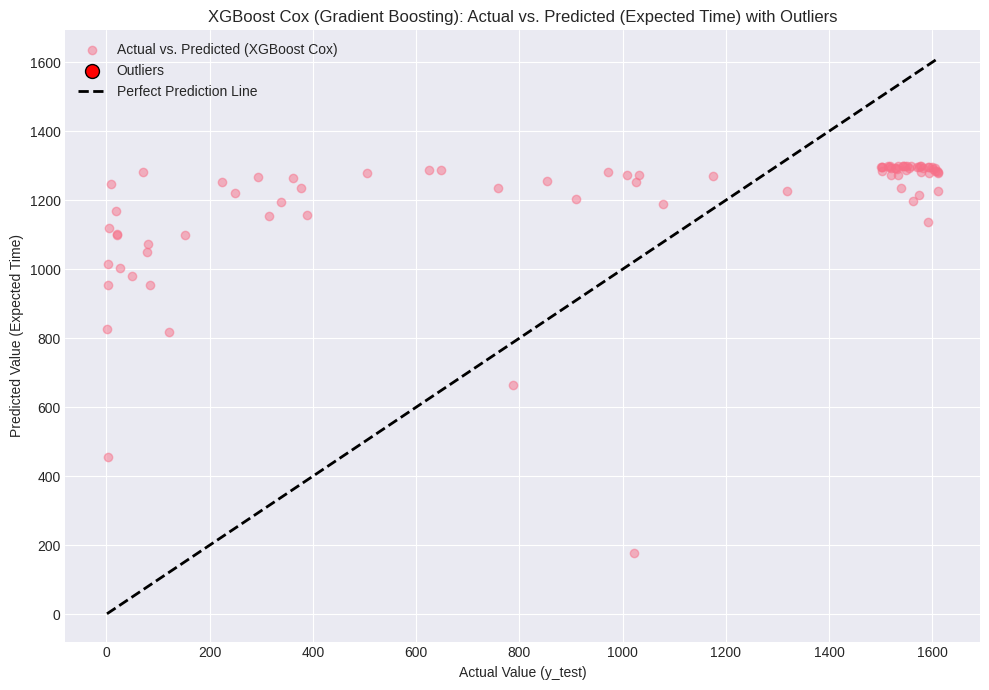


Number of outlier predictions: 0
Lower bound for residual outliers: -2504.25
Upper bound for residual outliers: 1945.51

--- Outlier Samples (Actual vs. Predicted Expected Time) ---
Empty DataFrame
Columns: [Actual, Predicted, Residual]
Index: []


In [53]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Get predicted risk scores for the test set using xgb_surv
risk_test_xgb_pred = xgb_surv.predict(X_test_sc)

# 2. Create a DataFrame with these risk scores for the cox_calibrator
# The cox_calibrator expects a DataFrame with a column named 'xgb_risk'
risk_df_for_calibrator_test = pd.DataFrame({'xgb_risk': risk_test_xgb_pred}, index=y_test.index)

# 3. Use cox_calibrator.predict_expectation to get a single predicted time for each test sample
# This will be the "predicted time" for our plot
predicted_time_xgb = cox_calibrator.predict_expectation(risk_df_for_calibrator_test)

# Align predicted_time_xgb with y_test if indices are different, or ensure they are Series/arrays
# predicted_time_xgb is a Series, y_test is a Series, both from the test set indices.

# 4. Calculate residuals
residuals_xgb = y_test - predicted_time_xgb

# 5. Calculate IQR for residuals to identify outliers
Q1_res_xgb = residuals_xgb.quantile(0.25)
Q3_res_xgb = residuals_xgb.quantile(0.75)
IQR_res_xgb = Q3_res_xgb - Q1_res_xgb

lower_bound_res_xgb = Q1_res_xgb - 1.5 * IQR_res_xgb
upper_bound_res_xgb = Q3_res_xgb + 1.5 * IQR_res_xgb

# Identify outlier residuals
outlier_mask_xgb = (residuals_xgb < lower_bound_res_xgb) | (residuals_xgb > upper_bound_res_xgb)

outlier_y_test_xgb = y_test[outlier_mask_xgb]
outlier_predicted_time_xgb = predicted_time_xgb[outlier_mask_xgb]

# 6. Plotting actual vs. predicted values with outliers highlighted
plt.figure(figsize=(10, 7))
plt.scatter(y_test, predicted_time_xgb, alpha=0.5, label='Actual vs. Predicted (XGBoost Cox)')
plt.scatter(outlier_y_test_xgb, outlier_predicted_time_xgb, color='red', s=100, label='Outliers', edgecolors='black')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Perfect Prediction Line')
plt.xlabel('Actual Value (y_test)')
plt.ylabel('Predicted Value (Expected Time)')
plt.title('XGBoost Cox (Gradient Boosting): Actual vs. Predicted (Expected Time) with Outliers')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"\nNumber of outlier predictions: {len(outlier_y_test_xgb)}")
print(f"Lower bound for residual outliers: {lower_bound_res_xgb:.2f}")
print(f"Upper bound for residual outliers: {upper_bound_res_xgb:.2f}")

print("\n--- Outlier Samples (Actual vs. Predicted Expected Time) ---")
outlier_df_xgb = pd.DataFrame({'Actual': outlier_y_test_xgb, 'Predicted': outlier_predicted_time_xgb, 'Residual': residuals_xgb[outlier_mask_xgb]})
print(outlier_df_xgb.to_string())

### Weibull AFT: Actual vs. Predicted (Expected Time) with Outliers

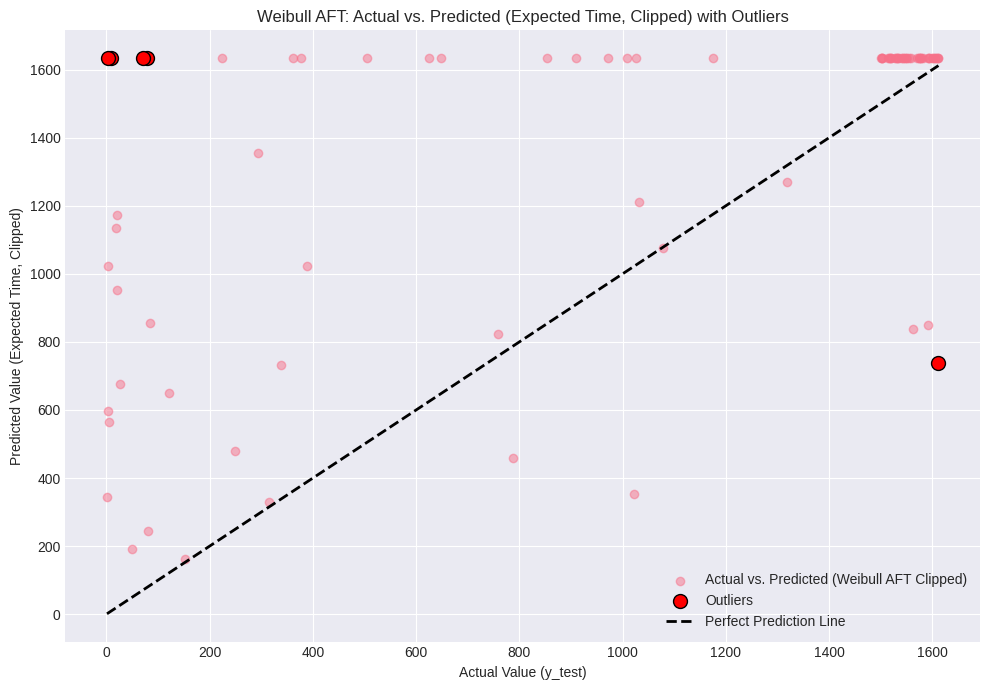


Number of outlier predictions: 5
Lower bound for residual outliers: -1495.17
Upper bound for residual outliers: 807.50

--- Outlier Samples (Actual vs. Predicted Expected Time, Clipped) ---
      Actual    Predicted     Residual
288        9  1634.000000 -1625.000000
894       78  1634.000000 -1556.000000
218       70  1634.000000 -1564.000000
202        2  1634.000000 -1632.000000
1234    1612   739.212236   872.787764


In [57]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Get predicted expected times for the test set using aft
# The aft model was fitted on cph_data_train_scaled, which includes 'time' and 'target'
# For prediction, it expects features only. Let's create a feature-only DataFrame for X_test_sc.
# We will use cph_data_test_scaled (without 'time' and 'target') as input.
# The `predict_expectation` method of AFTFitter expects a DataFrame of covariates.
predicted_time_aft = aft.predict_expectation(cph_data_test_scaled.drop(columns=['time', 'target']))

# Align predicted_time_aft with y_test
predicted_time_aft.index = y_test.index

# Apply clipping to ensure predicted expected times do not exceed the maximum observed time
# Re-using max_observed_time from previous calculation in cell AYC2a9vvoXYk
predicted_time_aft_clipped = np.clip(predicted_time_aft, None, max_observed_time)

# 2. Calculate residuals using clipped predictions
residuals_aft = y_test - predicted_time_aft_clipped

# 3. Calculate IQR for residuals to identify outliers
Q1_res_aft = residuals_aft.quantile(0.25)
Q3_res_aft = residuals_aft.quantile(0.75)
IQR_res_aft = Q3_res_aft - Q1_res_aft

lower_bound_res_aft = Q1_res_aft - 1.5 * IQR_res_aft
upper_bound_res_aft = Q3_res_aft + 1.5 * IQR_res_aft

# Identify outlier residuals
outlier_mask_aft = (residuals_aft < lower_bound_res_aft) | (residuals_aft > upper_bound_res_aft)

outlier_y_test_aft = y_test[outlier_mask_aft]
outlier_predicted_time_aft = predicted_time_aft_clipped[outlier_mask_aft]

# 4. Plotting actual vs. predicted values with outliers highlighted
plt.figure(figsize=(10, 7))
plt.scatter(y_test, predicted_time_aft_clipped, alpha=0.5, label='Actual vs. Predicted (Weibull AFT Clipped)')
plt.scatter(outlier_y_test_aft, outlier_predicted_time_aft, color='red', s=100, label='Outliers', edgecolors='black')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Perfect Prediction Line')
plt.xlabel('Actual Value (y_test)')
plt.ylabel('Predicted Value (Expected Time, Clipped)')
plt.title('Weibull AFT: Actual vs. Predicted (Expected Time, Clipped) with Outliers')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"\nNumber of outlier predictions: {len(outlier_y_test_aft)}")
print(f"Lower bound for residual outliers: {lower_bound_res_aft:.2f}")
print(f"Upper bound for residual outliers: {upper_bound_res_aft:.2f}")

print("\n--- Outlier Samples (Actual vs. Predicted Expected Time, Clipped) ---")
outlier_df_aft = pd.DataFrame({'Actual': outlier_y_test_aft, 'Predicted': outlier_predicted_time_aft, 'Residual': residuals_aft[outlier_mask_aft]})
print(outlier_df_aft.to_string())

This behavior is common in parametric survival models like Weibull AFT when they extrapolate significantly. If the model estimates a very low hazard rate for a particular combination of features (meaning a very low probability of the event occurring at any given time), its mathematical expectation of survival time can become extremely large. This might happen for samples whose feature values suggest a risk profile far outside the range of observed events in the training data, leading to predictions that are orders of magnitude larger than any actual observed time. These extreme predictions often indicate extrapolation or numerical instability rather than realistic outcomes.

### Neural Network: Actual vs. Predicted (Expected Time) with Outliers

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


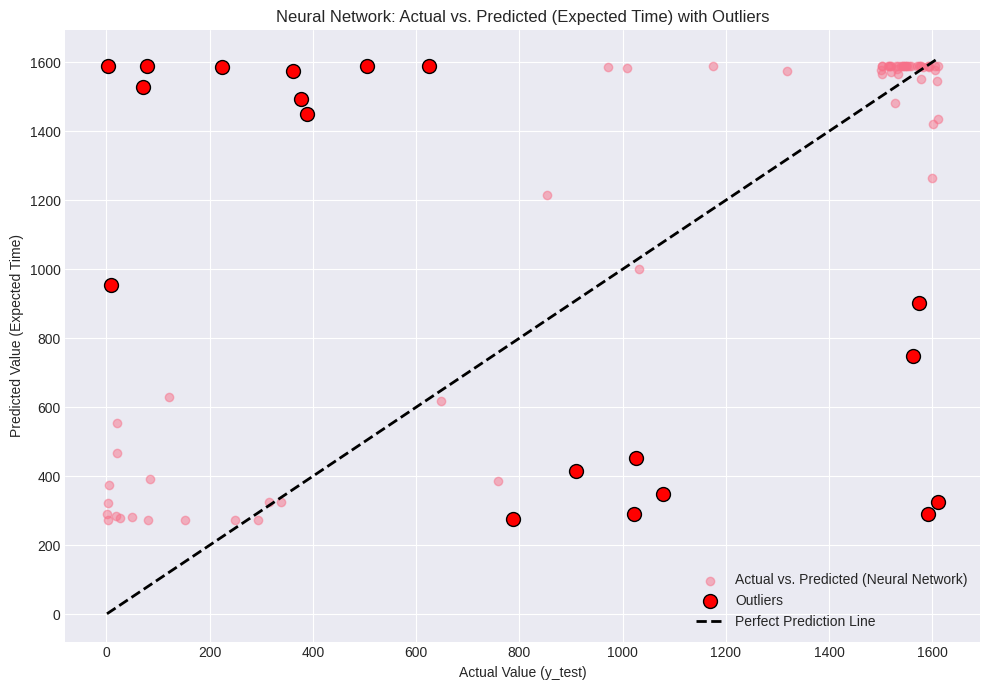


Number of outlier predictions: 19
Lower bound for residual outliers: -739.10
Upper bound for residual outliers: 474.02

--- Outlier Samples (Actual vs. Predicted Expected Time) ---
      Actual    Predicted     Residual
288        9   954.975142  -945.975142
847      505  1590.010544 -1085.010544
612     1079   348.520097   730.479903
894       78  1590.059236 -1512.059236
1063    1026   451.297801   574.702199
640     1592   291.036736  1300.963264
1364    1022   290.675200   731.324800
383      224  1586.635891 -1362.635891
218       70  1529.320173 -1459.320173
202        2  1589.829247 -1587.829247
542      377  1492.860208 -1115.860208
387      388  1448.776612 -1060.776612
1213     909   415.701892   493.298108
396     1575   902.218700   672.781300
1245     787   275.888620   511.111380
520     1563   747.558691   815.441309
92       361  1575.960322 -1214.960322
1299     624  1589.390795  -965.390795
1234    1612   325.472326  1286.527674


In [55]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Get predicted time scores for the test set using nn_model
# nn_model directly predicts time, which we then feed to the cox_calibrator_nn
predicted_nn_scores = nn_model_classification.predict(X_test_sc).flatten()

# 2. Create a DataFrame with these scores for the cox_calibrator_nn
# The cox_calibrator_nn expects a DataFrame with a column named 'nn_event_probability'
risk_df_for_calibrator_test_nn = pd.DataFrame({'nn_event_probability': predicted_nn_scores}, index=y_test.index)

# 3. Use cox_calibrator_nn.predict_expectation to get a single predicted time for each test sample
predicted_time_nn = cox_calibrator_nn.predict_expectation(risk_df_for_calibrator_test_nn)

# Align predicted_time_nn with y_test
predicted_time_nn.index = y_test.index

# 4. Calculate residuals
residuals_nn = y_test - predicted_time_nn

# 5. Calculate IQR for residuals to identify outliers
Q1_res_nn = residuals_nn.quantile(0.25)
Q3_res_nn = residuals_nn.quantile(0.75)
IQR_res_nn = Q3_res_nn - Q1_res_nn

lower_bound_res_nn = Q1_res_nn - 1.5 * IQR_res_nn
upper_bound_res_nn = Q3_res_nn + 1.5 * IQR_res_nn

# Identify outlier residuals
outlier_mask_nn = (residuals_nn < lower_bound_res_nn) | (residuals_nn > upper_bound_res_nn)

outlier_y_test_nn = y_test[outlier_mask_nn]
outlier_predicted_time_nn = predicted_time_nn[outlier_mask_nn]

# 6. Plotting actual vs. predicted values with outliers highlighted
plt.figure(figsize=(10, 7))
plt.scatter(y_test, predicted_time_nn, alpha=0.5, label='Actual vs. Predicted (Neural Network)')
plt.scatter(outlier_y_test_nn, outlier_predicted_time_nn, color='red', s=100, label='Outliers', edgecolors='black')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Perfect Prediction Line')
plt.xlabel('Actual Value (y_test)')
plt.ylabel('Predicted Value (Expected Time)')
plt.title('Neural Network: Actual vs. Predicted (Expected Time) with Outliers')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"\nNumber of outlier predictions: {len(outlier_y_test_nn)}")
print(f"Lower bound for residual outliers: {lower_bound_res_nn:.2f}")
print(f"Upper bound for residual outliers: {upper_bound_res_nn:.2f}")

print("\n--- Outlier Samples (Actual vs. Predicted Expected Time) ---")
outlier_df_nn = pd.DataFrame({'Actual': outlier_y_test_nn, 'Predicted': outlier_predicted_time_nn, 'Residual': residuals_nn[outlier_mask_nn]})
print(outlier_df_nn.to_string())

### Reservoir Network: Actual vs. Predicted (Expected Time) with Outliers

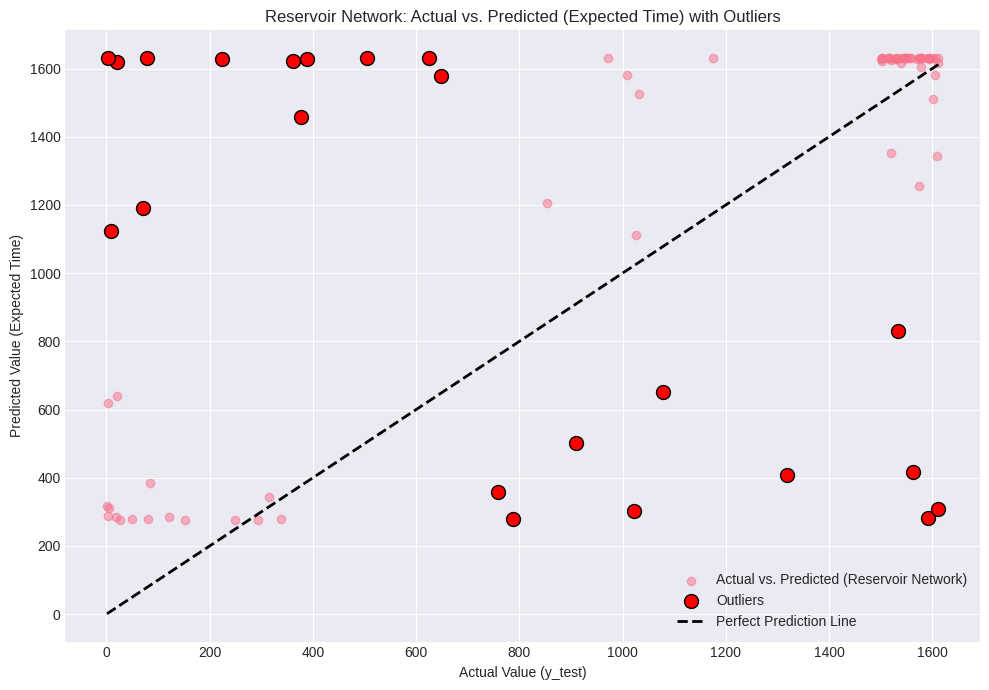


Number of outlier predictions: 22
Lower bound for residual outliers: -720.85
Upper bound for residual outliers: 389.03

--- Outlier Samples (Actual vs. Predicted Expected Time) ---
      Actual    Predicted     Residual
288        9  1124.133815 -1115.133815
847      505  1630.095031 -1125.095031
570       20  1620.169945 -1600.169945
612     1079   650.644898   428.355102
964     1534   830.858968   703.141032
894       78  1630.182638 -1552.182638
640     1592   280.887598  1311.112402
1364    1022   303.871471   718.128529
383      224  1629.259707 -1405.259707
218       70  1190.153500 -1120.153500
765     1319   407.996508   911.003492
202        2  1630.584588 -1628.584588
1027     649  1578.348272  -929.348272
542      377  1458.918252 -1081.918252
387      388  1626.826492 -1238.826492
1213     909   503.122662   405.877338
1245     787   278.471438   508.528562
520     1563   417.794328  1145.205672
92       361  1621.063719 -1260.063719
1001     759   359.290234   399.709766

In [40]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Get predicted time scores for the test set using rn_model
predicted_rn_scores = rn_model_classification.predict_proba(X_test_sc).flatten()

# 2. Create a DataFrame with these scores for the cox_calibrator_rn
# The cox_calibrator_rn expects a DataFrame with a column named 'rn_event_probability'
risk_df_for_calibrator_test_rn = pd.DataFrame({'rn_event_probability': predicted_rn_scores}, index=y_test.index)

# 3. Use cox_calibrator_rn.predict_expectation to get a single predicted time for each test sample
predicted_time_rn = cox_calibrator_rn.predict_expectation(risk_df_for_calibrator_test_rn)

# Align predicted_time_rn with y_test
predicted_time_rn.index = y_test.index

# 4. Calculate residuals
residuals_rn = y_test - predicted_time_rn

# 5. Calculate IQR for residuals to identify outliers
Q1_res_rn = residuals_rn.quantile(0.25)
Q3_res_rn = residuals_rn.quantile(0.75)
IQR_res_rn = Q3_res_rn - Q1_res_rn

lower_bound_res_rn = Q1_res_rn - 1.5 * IQR_res_rn
upper_bound_res_rn = Q3_res_rn + 1.5 * IQR_res_rn

# Identify outlier residuals
outlier_mask_rn = (residuals_rn < lower_bound_res_rn) | (residuals_rn > upper_bound_res_rn)

outlier_y_test_rn = y_test[outlier_mask_rn]
outlier_predicted_time_rn = predicted_time_rn[outlier_mask_rn]

# 6. Plotting actual vs. predicted values with outliers highlighted
plt.figure(figsize=(10, 7))
plt.scatter(y_test, predicted_time_rn, alpha=0.5, label='Actual vs. Predicted (Reservoir Network)')
plt.scatter(outlier_y_test_rn, outlier_predicted_time_rn, color='red', s=100, label='Outliers', edgecolors='black')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Perfect Prediction Line')
plt.xlabel('Actual Value (y_test)')
plt.ylabel('Predicted Value (Expected Time)')
plt.title('Reservoir Network: Actual vs. Predicted (Expected Time) with Outliers')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"\nNumber of outlier predictions: {len(outlier_y_test_rn)}")
print(f"Lower bound for residual outliers: {lower_bound_res_rn:.2f}")
print(f"Upper bound for residual outliers: {upper_bound_res_rn:.2f}")

print("\n--- Outlier Samples (Actual vs. Predicted Expected Time) ---")
outlier_df_rn = pd.DataFrame({'Actual': outlier_y_test_rn, 'Predicted': outlier_predicted_time_rn, 'Residual': residuals_rn[outlier_mask_rn]})
print(outlier_df_rn.to_string())

# Test how prediction works

In [58]:
original_test_sample_index = X_test.index[0]
original_test_sample = X_test.loc[[original_test_sample_index]]

print("\nOriginal (unscaled) features of the selected test sample:")
display(original_test_sample)



Original (unscaled) features of the selected test sample:


,doctor,age,af,dm,ckd,copd,insult,onco,severity,nstemi,...,pulm_cong,bmi,smoking,hb,leukoc,tromboc,t_chol,ldl,glu,crea
528,1,71.0,0,0,1,0,0,0,0,0,...,0,31.4,0,160.0,8.5,190.0,4.9,2.85,3.8,118.0


Selected test sample (first row of X_test_sc) with features:
     doctor     age        af        dm       ckd      copd    insult  \
0 -1.285268 -0.7533 -0.479174 -0.513785 -0.435957 -0.244736 -0.320907   

       onco  severity    nstemi  ...  pulm_cong       bmi   smoking        hb  \
0 -0.111525 -1.288461 -0.386933  ...  -0.325543 -1.059906  1.396165  1.006154   

     leukoc   tromboc    t_chol       ldl       glu      crea  
0 -0.209698 -1.209579 -0.631598 -0.490307 -0.647956  0.410728  

[1 rows x 30 columns]

Predicted XGBoost Cox risk score for the sample: 0.3466


<Figure size 1000x600 with 0 Axes>

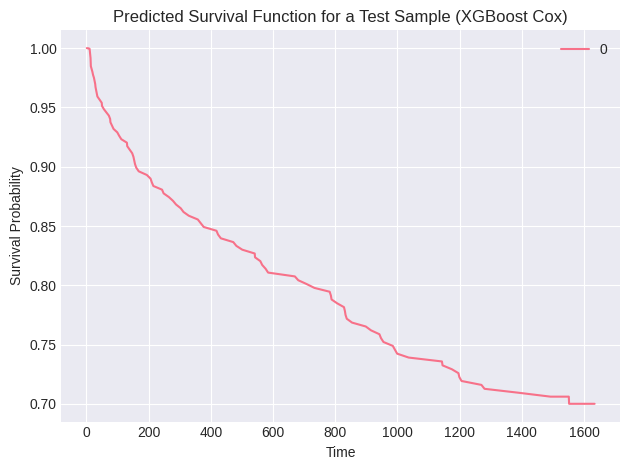


Interpretation: This plot shows the estimated probability of survival over time for the selected test sample, based on the XGBoost Cox model. The curve starts at 1 (100% survival) at time 0 and decreases as time progresses, indicating the likelihood of the event occurring.


In [59]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Get a TEST sample ---
# For demonstration, let's select the first sample from the scaled test set
# X_test_sc is a numpy array, take the first row and reshape for single prediction
single_test_sample_scaled = X_test_sc[0].reshape(1, -1)

# Create a DataFrame for clarity, using the original feature names
single_test_sample_df = pd.DataFrame(single_test_sample_scaled, columns=original_features)

print(f"Selected test sample (first row of X_test_sc) with features:\n{single_test_sample_df}")

# --- Use XGBoost Cox (Gradient Boosting) to predict risk score ---
# The xgb_surv model was trained in a previous cell
predicted_risk_score_xgb = xgb_surv.predict(single_test_sample_scaled)

print(f"\nPredicted XGBoost Cox risk score for the sample: {predicted_risk_score_xgb[0]:.4f}")

# --- Evaluate survival function using the Cox calibrator ---
# The cox_calibrator was fitted using xgb_risk as a covariate
# We need to create a DataFrame with a 'xgb_risk' column for prediction
risk_data_for_calibrator_single = pd.DataFrame({
    'xgb_risk': predicted_risk_score_xgb
})

survival_function_xgb_sample = cox_calibrator.predict_survival_function(risk_data_for_calibrator_single)

# --- Plot the survival function ---
plt.figure(figsize=(10, 6))
survival_function_xgb_sample.plot()
plt.title('Predicted Survival Function for a Test Sample (XGBoost Cox)')
plt.xlabel('Time')
plt.ylabel('Survival Probability')
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nInterpretation: This plot shows the estimated probability of survival over time for the selected test sample, based on the XGBoost Cox model. The curve starts at 1 (100% survival) at time 0 and decreases as time progresses, indicating the likelihood of the event occurring.")


SHAP values for the single test sample (first row of X_test_sc):
     doctor       age        af        dm       ckd     copd    insult  onco  severity    nstemi     stemi       llo   gender  ca_delay   sum_cad  stenting  total_revasc   ef_hosp       bpm     sysAP  pulm_cong       bmi   smoking        hb    leukoc   tromboc    t_chol       ldl       glu      crea
0  0.679554 -0.688564 -0.084913  0.087966  0.002493  0.00764 -0.007597   0.0 -0.065344 -0.000271 -0.006853 -0.002849  0.00053  0.047137 -0.222849   -0.0106     -0.004027 -0.314756  0.191865  0.018358  -0.059984  0.295226  0.081131 -0.639678  0.018285  0.003179  0.075321  0.015677 -0.512335  0.072449



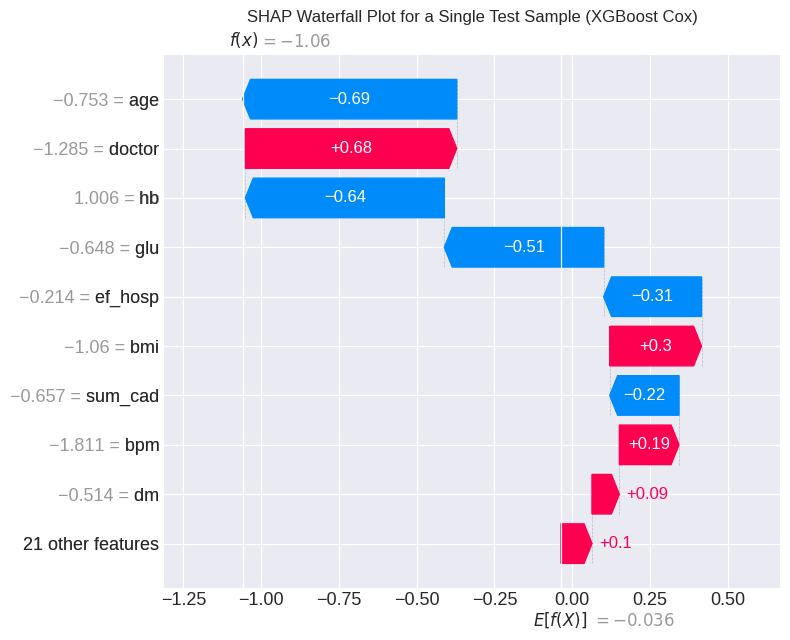


Interpretation of the Waterfall Plot:
- The Waterfall plot visualizes the individual feature contributions to a single prediction.
- The base value (E[f(x)]) is the average prediction across the dataset (or background dataset for KernelExplainer).
- Each bar shows how a feature's value pushes the prediction from the base value to the final output value (f(x)).
- Positive SHAP values (red bars) indicate features that increase the predicted risk score (meaning lower survival probability). 
- Negative SHAP values (blue bars) indicate features that decrease the predicted risk score (meaning higher survival probability).
- The length and direction of the bar indicate the magnitude and direction of the feature's impact.


In [43]:
import shap
import matplotlib.pyplot as plt

# Assuming xgb_surv is the trained XGBoost Cox model and single_test_sample_scaled
# is the scaled single sample (from PHjZTTz0fg_I)
# and original_features contains the feature names.

# Initialize the SHAP TreeExplainer for the XGBoost model
explainer_single_sample = shap.TreeExplainer(xgb_surv)

# Calculate SHAP values for the single test sample
# single_test_sample_scaled is a 2D array, so we need to pass it as is.
# shap_values_single will be a list of arrays if multi-output, or a single array if single-output.
shap_values_single = explainer_single_sample.shap_values(single_test_sample_scaled)

# Ensure shap_values_single is a single array for single-output models
# If it's a list with one element, extract it.
if isinstance(shap_values_single, list):
    shap_values_single = shap_values_single[0]

# Ensure single_test_sample_df (the DataFrame version of the single scaled sample)
# is available from the previous cell or recreate it for context.
# It was created in PHjZTTz0fg_I, but let's make sure it's accessible.
single_test_sample_df = pd.DataFrame(single_test_sample_scaled, columns=original_features)

print(f"\nSHAP values for the single test sample (first row of X_test_sc):\n{pd.DataFrame(shap_values_single.reshape(1, -1), columns=original_features).to_string()}\n")

# Visualize the SHAP values for this single sample using a waterfall plot
shap.initjs()
plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap.Explanation(
    values=shap_values_single[0], # Corrected: Pass the single explanation from the array
    base_values=explainer_single_sample.expected_value,
    data=single_test_sample_df.iloc[0],
    feature_names=original_features
), show=False) # show=False to allow plt.tight_layout()
plt.title('SHAP Waterfall Plot for a Single Test Sample (XGBoost Cox)')
plt.tight_layout()
plt.show()

print("\nInterpretation of the Waterfall Plot:")
print("- The Waterfall plot visualizes the individual feature contributions to a single prediction.")
print("- The base value (E[f(x)]) is the average prediction across the dataset (or background dataset for KernelExplainer).")
print("- Each bar shows how a feature's value pushes the prediction from the base value to the final output value (f(x)).")
print("- Positive SHAP values (red bars) indicate features that increase the predicted risk score (meaning lower survival probability). ")
print("- Negative SHAP values (blue bars) indicate features that decrease the predicted risk score (meaning higher survival probability).")
print("- The length and direction of the bar indicate the magnitude and direction of the feature's impact.")